<h1><center><font size="5">Sales Analysis for Store</font></center></h1>
<center><img src="https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcS-c97xz_bY5BFvplS28L1LxUBcIo5Pu_AVzw&s" width="600"></img></center>

* 1) First, download the data file, load it
        1. Describe the data
        2. Clean the data 
        3. Check the data for missing values or duplicates and carry out proper correction methods
        4. Visualize the data using proper visualization methods. 
        5. Carry out required correlation analysis 
* 2) Carry out any required preprocessing operations on the data 
* 3) Encode the labels

<!-- هذا هو جدول المحتويات -->
<div id="toc">
    <h2>Table of Contents</h2>
    <ul>
        <li><a href="#1">1. Set-up</a></li>
        <ul>
            <li><a href="#1.1">1.1 Import Libraries</a></li>
            <li><a href="#1.2">1.2 Web Scraping</a></li>
            <li><a href="#1.3">1.3 Import Data</a></li>
            <li><a href="#1.4">1.4 What Sales Analysis for Store and Why Is It Important?</a></li>
            <li><a href="#1.5">1.5 Dataset Tables</a></li>
        </ul>
        <li><a href="#2">2. Cleaning The Datasets</a></li>
        <ul>
            <li><a href="#2.1">2.1 Using `df.info()` to Check the Data Types of Columns</a></li>
            <li><a href="#2.2">2.2 Clean the Data by Fixing Errors Using `apply()`</a></li>
            <li><a href="#2.3">2.3 Check for Duplicates</a></li>
            <li><a href="#2.4">2.4 Check for Missing Values</a></li>
            <li><a href="#2.5">2.5 Detect and Analyze Outliers</a></li>
            <ul>
                <li><a href="#2.5.1">2.5.1 Outliers in Price</a></li>
                <li><a href="#2.5.2">2.5.2 Outliers in Quantity</a></li>
            </ul>
            <li><a href="#2.6">2.6 the Categorical Columns</a></li>
            <ul>
                <li><a href="#2.6.1">2.6.1 Handling the OrderDate Column for Type Conversion</a></li>
                <li><a href="#2.6.2">2.6.2 Adding a Season Column</a></li>
                <li><a href="#2.6.3">2.6.3 Merge the two columns to create a single column named Employee Name</a></li>
            </ul>
            <li><a href="#2.7">2.7 the Numerical Columns</a></li>
            <ul>
                <li><a href="#2.7.1">2.7.1 Handling the OrderDate column and convert it to the datetime type</a></li>
                <li><a href="#2.7.2">2.7.2 Adding two columns to the Customers table (Total_Orders, Total_Spent)</a></li>
                <li><a href="#2.7.3">2.7.3 Adding two columns to the Employees table (Total_Orders, Total_Spent)</a></li>
                <li><a href="#2.7.4">2.7.4 Adding a new Column named Available</a></li>
                <li><a href="#2.7.5">2.7.5 Adding PriceSegment Column and Chart for Distribution</a></li>
                <li><a href="#2.7.6">2.7.6 Adding a new column named Product_Count on Suppliers Table and Chart for Distribution</a></li>
                <li><a href="#2.7.7">2.7.7 Adding a new column named TotalOrders on Shippers Table and Chart for Distribution</a></li>
            </ul>
        </ul>
        <li><a href="#3">3. Exploring and Visualizing</a></li>
        <ul>
            <li><a href="#3.1">3.1 Top 10 Customers: Number of Orders and Total Spent($)</a></li>
            <li><a href="#3.2">3.2 Total Expenditure by Country: A Breakdown of Spending Across Regions</a></li>
            <li><a href="#3.3">3.3 Total Sales by City and Country</a></li>
            <li><a href="#3.4">3.4 Total Sales per Order per Month and Year</a></li>
            <li><a href="#3.5">3.5 Difference Between Available and Ordered Quantities by Category</a></li>
            <li><a href="#3.6">3.6 Stock Difference for Each Product</a></li>
            <li><a href="#3.7">3.7 Total Sales by Season</a></li>
            <li><a href="#3.8">3.8 Total Sales by Product and Category</a></li>
            <li><a href="#3.9">3.9 Comparison of Total Sales and Total Quantity per Category, Product and Supplier</a></li>
            <li><a href="#3.10">3.10 Total sales by price segment</a></li>
            <li><a href="#3.11">3.11 Number of Orders and Total Sales Per Employee</a></li>
            <li><a href="#3.12">3.12 Total Sales and Total Orders in Each Shipper Company</a></li>
        </ul>
        <li><a href="#4">4. Insights</a></li>
        <li><a href="#5">5. Recommends</a></li>
    </ul>
</div>


<a id="1"></a>
# <b>1 <span style='color:#F1A424'>|</span> Set-up</b>

# <a id="1.1"></a>
## <b>1.1 <span style='color:#F1A424'>Import Libraries</span></b>

In [1]:
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
import pandas as pd
import time
from io import StringIO
import sys
import traceback
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

<a href="#toc" role="button" aria-pressed="true">🔝 Back to Table of Contents 🔝</a>

<a id="1.2"></a>
## <b>1.2 <span style='color:#F1A424'>Web Scraping</span></b>

In [2]:
# إعداد المتصفح
options = webdriver.ChromeOptions()
options.page_load_strategy = 'none'
driver = webdriver.Chrome(options=options)

url = "https://www.w3schools.com/sql/trysql.asp?filename=trysql_customers"
driver.get(url)

# طباعة ديناميكية
def print_dynamic_message(message, color_code="0"):
    colors = {
        "success": "\033[92m",
        "error": "\033[91m",
        "warning": "\033[93m",
        "info": "\033[94m"
    }
    color = colors.get(color_code, "\033[0m")
    sys.stdout.write(color + message + "\033[0m\n")
    time.sleep(1)

print_dynamic_message("🎉 الصفحة تم فتحها بنجاح!", "info")
print_dynamic_message(f"🌐 العنوان الحالي: {url}", "info")
print_dynamic_message("⏳ جاري تحميل الصفحة، يرجى الانتظار...", "info")

# انتظار تحميل المحرر داخل الصفحة
time.sleep(25)

# قائمة الجداول
tables_to_extract = [
    "Customers", "Categories", "Employees", "OrderDetails",
    "Orders", "Products", "Shippers", "Suppliers"
]

print_dynamic_message("📋 الجداول التي سيتم استخراجها:", "info")
for i, table in enumerate(tables_to_extract, 1):
    print_dynamic_message(f"{i}. {table}", "info")
print_dynamic_message("🔄 بدء العملية التلقائية الآن...", "warning")

# استخراج البيانات من كل جدول
for idx, table_name in enumerate(tables_to_extract, 1):
    print_dynamic_message(f"\n🎯 استخراج الجدول {idx}: {table_name}...", "info")
    
    try:
        # تنفيذ الاستعلام داخل المحرر
        driver.execute_script(f"editor.setValue('SELECT * FROM {table_name};');")
        driver.execute_script("w3schoolsSQLSubmit();")

        # طباعة الاستعلام الحالي للتأكد
        current_query = driver.execute_script("return editor.getValue();")
        print_dynamic_message(f"📄 الاستعلام الحالي: {current_query}", "info")

        # انتظار تحميل iframe والانتقال إليه
        WebDriverWait(driver, 15).until(
            EC.frame_to_be_available_and_switch_to_it((By.ID, "iframeResultSQL"))
        )

        # انتظار ظهور الجدول داخل iframe
        WebDriverWait(driver, 20).until(
            EC.presence_of_element_located((By.TAG_NAME, "table"))
        )

        # استخراج الجدول
        table = driver.find_element(By.TAG_NAME, "table")
        html = table.get_attribute("outerHTML")

        # تحويل إلى DataFrame
        df = pd.read_html(StringIO(html))[0]
        df = df.map(lambda x: x.strip() if isinstance(x, str) else x)
        df.dropna(how='all', inplace=True)

        # حفظ الملف
        filename = f"w3_{table_name}.csv"
        df.to_csv(filename, index=False, encoding='utf-8-sig')
        print_dynamic_message(f"✅ تم حفظ الجدول '{table_name}' في الملف: {filename}", "success")

        # العودة إلى الصفحة الرئيسية
        driver.switch_to.default_content()
        time.sleep(2)

    except Exception as e:
        print_dynamic_message(f"⚠ خطأ أثناء استخراج الجدول '{table_name}':", "error")
        traceback.print_exc()
        driver.switch_to.default_content()

# إنهاء العملية
print_dynamic_message("\n🎉-------------------- انتهت العملية بنجاح! --------------------🎉", "success")
print_dynamic_message("📂 تم استخراج جميع الجداول وحفظها في ملفات CSV.", "success")
driver.quit()
print_dynamic_message("🔴 تم إغلاق المتصفح.", "info")


🎉 الصفحة تم فتحها بنجاح!
🌐 العنوان الحالي: https://www.w3schools.com/sql/trysql.asp?filename=trysql_customers
⏳ جاري تحميل الصفحة، يرجى الانتظار...
📋 الجداول التي سيتم استخراجها:
1. Customers
2. Categories
3. Employees
4. OrderDetails
5. Orders
6. Products
7. Shippers
8. Suppliers
🔄 بدء العملية التلقائية الآن...

🎯 استخراج الجدول 1: Customers...
📄 الاستعلام الحالي: SELECT * FROM Customers;
✅ تم حفظ الجدول 'Customers' في الملف: w3_Customers.csv

🎯 استخراج الجدول 2: Categories...
📄 الاستعلام الحالي: SELECT * FROM Categories;
✅ تم حفظ الجدول 'Categories' في الملف: w3_Categories.csv

🎯 استخراج الجدول 3: Employees...
📄 الاستعلام الحالي: SELECT * FROM Employees;
✅ تم حفظ الجدول 'Employees' في الملف: w3_Employees.csv

🎯 استخراج الجدول 4: OrderDetails...
📄 الاستعلام الحالي: SELECT * FROM OrderDetails;
✅ تم حفظ الجدول 'OrderDetails' في الملف: w3_OrderDetails.csv

🎯 استخراج الجدول 5: Orders...
📄 الاستعلام الحالي: SELECT * FROM Orders;
✅ تم حفظ الجدول 'Orders' في الملف: w3_Orders.csv

🎯 استخراج ا

<a href="#toc" role="button" aria-pressed="true">🔝 Back to Table of Contents 🔝</a>

<a id="1.3"></a>
## <b>1.3 <span style='color:#F1A424'>Import Data</span></b>

In [3]:
# قراءة الجداول
df_Customers =  pd.read_csv("w3_Customers.csv", encoding="utf-8-sig")
df_Orders =  pd.read_csv("w3_Orders.csv", encoding="utf-8-sig")
df_OrderDetails =  pd.read_csv("w3_OrderDetails.csv", encoding="utf-8-sig")
df_Products =  pd.read_csv("w3_Products.csv", encoding="utf-8-sig")
df_Employees =  pd.read_csv("w3_Employees.csv", encoding="utf-8-sig")
df_Categories =  pd.read_csv("w3_Categories.csv", encoding="utf-8-sig")
df_Shippers =  pd.read_csv("w3_Shippers.csv", encoding="utf-8-sig")
df_Suppliers =  pd.read_csv("w3_Suppliers.csv", encoding="utf-8-sig")

<a href="#toc" role="button" aria-pressed="true">🔝 Back to Table of Contents 🔝</a>

<a id="1.4"></a>
## <b>1.4 <span style='color:#F1A424'>What Sales Analysis for Store and why is it important?</span></b>

Sales data analysis helps companies understand performance patterns and market trends. By studying product sales,
customer behavior, employee performance, and suppliers, we can identify factors that influence growth and revenue.
This analysis enables strategic decision-making to improve performance and increase profitability.
The focus of this analysis is on high-priced products, seasonal fluctuations, and geographical distribution.

Key Questions for the Analysis:

Which high-priced products generate the most revenue?

How do different seasons affect product sales?

Which categories achieve the highest sales?

How does inventory shortage impact the company's ability to fulfill orders?

Do promotional campaigns influence sales growth?

How do price differences between products affect revenue?

How does geographical distribution impact product sales?

What is the relationship between the number of orders and revenue?

Are there products that have seen significant sales growth?

Objective of the Analysis:

The goal of the analysis is to provide comprehensive insights to improve marketing and distribution strategies,
ensure better inventory management, and increase profitability.
It helps in demand forecasting and achieving sustainable sales growth over the long term.

<a href="#toc" role="button" aria-pressed="true">🔝 Back to Table of Contents 🔝</a>

<a id="1.5"></a>
## <b>1.5 <span style='color:#F1A424'>Dataset Tables</span></b> 

In [4]:
df_Customers.head()

,CustomerID,CustomerName,ContactName,Address,City,PostalCode,Country
0,1,Alfreds Futterkiste,Maria Anders,Obere Str. 57,Berlin,12209,Germany
1,2,Ana Trujillo Emparedados y helados,Ana Trujillo,Avda. de la Constitución 2222,México D.F.,05021,Mexico
2,3,Antonio Moreno Taquería,Antonio Moreno,Mataderos 2312,México D.F.,05023,Mexico
3,4,Around the Horn,Thomas Hardy,120 Hanover Sq.,London,WA1 1DP,UK
4,5,Berglunds snabbköp,Christina Berglund,Berguvsvägen 8,Luleå,S-958 22,Sweden


In [5]:
df_Employees.head()

,EmployeeID,LastName,FirstName,BirthDate,Photo,Notes
0,1,Davolio,Nancy,12/8/1968,EmpID1.pic,Education includes a BA in psychology from Col...
1,2,Fuller,Andrew,2/19/1952,EmpID2.pic,Andrew received his BTS commercial and a Ph.D....
2,3,Leverling,Janet,8/30/1963,EmpID3.pic,Janet has a BS degree in chemistry from Boston...
3,4,Peacock,Margaret,9/19/1958,EmpID4.pic,Margaret holds a BA in English literature from...
4,5,Buchanan,Steven,3/4/1955,EmpID5.pic,Steven Buchanan graduated from St. Andrews Uni...


In [6]:
df_Suppliers.head()

,SupplierID,SupplierName,ContactName,Address,City,PostalCode,Country,Phone
0,1,Exotic Liquid,Charlotte Cooper,49 Gilbert St.,Londona,EC1 4SD,UK,(171) 555-2222
1,2,New Orleans Cajun Delights,Shelley Burke,P.O. Box 78934,New Orleans,70117,USA,(100) 555-4822
2,3,Grandma Kelly's Homestead,Regina Murphy,707 Oxford Rd.,Ann Arbor,48104,USA,(313) 555-5735
3,4,Tokyo Traders,Yoshi Nagase,9-8 Sekimai Musashino-shi,Tokyo,100,Japan,(03) 3555-5011
4,5,Cooperativa de Quesos 'Las Cabras',Antonio del Valle Saavedra,Calle del Rosal 4,Oviedo,33007,Spain,(98) 598 76 54


In [7]:
df_Shippers.head()

,ShipperID,ShipperName,Phone
0,1,Speedy Express,(503) 555-9831
1,2,United Package,(503) 555-3199
2,3,Federal Shipping,(503) 555-9931


In [8]:
df_Categories.head()

,CategoryID,CategoryName,Description
0,1,Beverages,"Soft drinks, coffees, teas, beers, and ales"
1,2,Condiments,"Sweet and savory sauces, relishes, spreads, an..."
2,3,Confections,"Desserts, candies, and sweet breads"
3,4,Dairy Products,Cheeses
4,5,Grains/Cereals,"Breads, crackers, pasta, and cereal"


In [9]:
df_Products.head()

,ProductID,ProductName,SupplierID,CategoryID,Unit,Price
0,1,Chais,1,1,10 boxes x 20 bags,18.00
1,2,Chang,1,1,24 - 12 oz bottles,19.00
2,3,Aniseed Syrup,1,2,12 - 550 ml bottles,10.00
3,4,Chef Anton's Cajun Seasoning,2,2,48 - 6 oz jars,22.00
4,5,Chef Anton's Gumbo Mix,2,2,36 boxes,21.35


In [10]:
df_Orders.head()

,OrderID,CustomerID,EmployeeID,OrderDate,ShipperID
0,10248,90,5,7/4/1996,3
1,10249,81,6,7/5/1996,1
2,10250,34,4,7/8/1996,2
3,10251,84,3,7/8/1996,1
4,10252,76,4,7/9/1996,2


In [11]:
df_OrderDetails.head()

,OrderDetailID,OrderID,ProductID,Quantity
0,1,10248,11,12
1,2,10248,42,10
2,3,10248,72,5
3,4,10249,14,9
4,5,10249,51,40


In [12]:
# دمج جدول OrderDetails مع جدول Products للحصول على السعر
order_details_with_price = pd.merge(df_OrderDetails, df_Products[['ProductID','Price']], on='ProductID', how='inner')

# حساب إجمالي السعر لكل منتج في الطلب (Quantity * Price)
order_details_with_price['Total Price'] = order_details_with_price['Quantity'] * order_details_with_price['Price']

# تجميع البيانات حسب OrderID لحساب الإجمالي الكلي لكل طلب
order_totals = order_details_with_price.groupby('OrderID')['Total Price'].sum().reset_index(name='Total Sales')

# دمج النتيجة مع جدول Orders لإضافة عمود "Total Sales" في جدول Orders
df_Orders_with_total = pd.merge(df_Orders, order_totals, on='OrderID', how='left')

# حساب إجمالي عدد الطلبات (OrderID) لكل عميل
customer_order_count = df_Orders_with_total.groupby('CustomerID')['OrderID'].nunique().reset_index(name='Total Orders')

# دمج النتيجة مع جدول Orders_with_total للحصول على إجمالي عدد الطلبات لكل عميل في كل طلب
df_Orders_with_total = pd.merge(df_Orders_with_total, customer_order_count, on='CustomerID', how='left')

# تحويل عمود OrderDate إلى نوع بيانات datetime
df_Orders_with_total['OrderDate'] = pd.to_datetime(df_Orders_with_total['OrderDate'], errors='coerce')

# إضافة عمود للسنة (Year)
df_Orders_with_total['Year'] = df_Orders_with_total['OrderDate'].dt.year

# إضافة عمود للشهر (Month)
df_Orders_with_total['Month'] = df_Orders_with_total['OrderDate'].dt.month

# إعادة ترتيب الأعمدة ليكون "Total Sales" و "Total Orders" في آخر الأعمدة
final_columns_order = [
    'OrderID', 'CustomerID', 'EmployeeID', 'OrderDate', 'ShipperID', 
    'Year', 'Month','Total Orders' , 'Total Sales'
]

# إعادة ترتيب الأعمدة
df_Orders_with_total = df_Orders_with_total[final_columns_order]

# عرض النتيجة النهائية
df_Orders_with_total


,OrderID,CustomerID,EmployeeID,OrderDate,ShipperID,Year,Month,Total Orders,Total Sales
0,10248,90,5,1996-07-04,3,1996,7,1,566.00
1,10249,81,6,1996-07-05,1,1996,7,2,2329.25
2,10250,34,4,1996-07-08,2,1996,7,2,2267.25
3,10251,84,3,1996-07-08,1,1996,7,2,839.50
4,10252,76,4,1996-07-09,2,1996,7,2,4662.50
...,...,...,...,...,...,...,...,...,...
191,10439,51,6,1997-02-07,3,1997,2,5,1348.70
192,10440,71,4,1997-02-10,2,1997,2,4,7246.01
193,10441,55,3,1997-02-10,2,1997,2,4,2195.00
194,10442,20,3,1997-02-11,2,1997,2,10,2246.00


<a href="#toc" role="button" aria-pressed="true">🔝 Back to Table of Contents 🔝</a>

<a id="2"></a>
# <b>2 <span style='color:#F1A424'>|</span> Cleaning The dataset</b>

<a id="2.1"></a>
## <b>2.1 <span style='color:#F1A424'>Using df.info() to Check the Data Types of Columns</span></b> 

In [14]:
df_Customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 91 entries, 0 to 90
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   CustomerID    91 non-null     int64 
 1   CustomerName  91 non-null     object
 2   ContactName   91 non-null     object
 3   Address       91 non-null     object
 4   City          91 non-null     object
 5   PostalCode    90 non-null     object
 6   Country       91 non-null     object
dtypes: int64(1), object(6)
memory usage: 5.1+ KB


In [15]:
df_Employees.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   EmployeeID  10 non-null     int64 
 1   LastName    10 non-null     object
 2   FirstName   10 non-null     object
 3   BirthDate   10 non-null     object
 4   Photo       10 non-null     object
 5   Notes       10 non-null     object
dtypes: int64(1), object(5)
memory usage: 612.0+ bytes


In [16]:
df_Suppliers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29 entries, 0 to 28
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   SupplierID    29 non-null     int64 
 1   SupplierName  29 non-null     object
 2   ContactName   29 non-null     object
 3   Address       29 non-null     object
 4   City          29 non-null     object
 5   PostalCode    29 non-null     object
 6   Country       29 non-null     object
 7   Phone         29 non-null     object
dtypes: int64(1), object(7)
memory usage: 1.9+ KB


In [17]:
df_Shippers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3 entries, 0 to 2
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   ShipperID    3 non-null      int64 
 1   ShipperName  3 non-null      object
 2   Phone        3 non-null      object
dtypes: int64(1), object(2)
memory usage: 204.0+ bytes


In [18]:
df_Categories.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   CategoryID    8 non-null      int64 
 1   CategoryName  8 non-null      object
 2   Description   8 non-null      object
dtypes: int64(1), object(2)
memory usage: 324.0+ bytes


In [19]:
df_Products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 77 entries, 0 to 76
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   ProductID    77 non-null     int64  
 1   ProductName  77 non-null     object 
 2   SupplierID   77 non-null     int64  
 3   CategoryID   77 non-null     int64  
 4   Unit         77 non-null     object 
 5   Price        77 non-null     float64
dtypes: float64(1), int64(3), object(2)
memory usage: 3.7+ KB


In [20]:
df_Orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 196 entries, 0 to 195
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   OrderID     196 non-null    int64 
 1   CustomerID  196 non-null    int64 
 2   EmployeeID  196 non-null    int64 
 3   OrderDate   196 non-null    object
 4   ShipperID   196 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.8+ KB


In [21]:
df_OrderDetails.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 518 entries, 0 to 517
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   OrderDetailID  518 non-null    int64
 1   OrderID        518 non-null    int64
 2   ProductID      518 non-null    int64
 3   Quantity       518 non-null    int64
dtypes: int64(4)
memory usage: 16.3 KB


<a href="#toc" role="button" aria-pressed="true">🔝 Back to Table of Contents 🔝</a>

<a id="2.2"></a>
## <b>2.2 <span style='color:#F1A424'>Clean the Data by Fixing Errors Using `apply()`</span></b>

In [22]:
def remove_extra_spaces(df):
    """
    Takes a DataFrame and removes extra spaces from all text columns.
    """
    # تحديد الأعمدة النصية فقط
    text_columns = df.select_dtypes(include=['object']).columns
    
    # تطبيق strip() على جميع الأعمدة النصية لإزالة المسافات الزائدة
    df[text_columns] = df[text_columns].apply(lambda x: x.str.strip())
    return df

# قائمة الجداول
dfs = {
    'Customers': df_Customers,
    'Employees': df_Employees,
    'Suppliers': df_Suppliers,
    'Shippers': df_Shippers,
    'Categories':df_Categories,
    'Products': df_Products,
    'Orders': df_Orders,
    'OrderDetails': df_OrderDetails
}

# التكرار على كل جدول في القاموس وتطبيق دالة إزالة المسافات
for name, df in dfs.items():
    print(f"Cleaning {name} dataset:")
    
    # تطبيق دالة إزالة المسافات الزائدة
    cleaned_df = remove_extra_spaces(df)
    
    # يمكنك طباعة أول 5 صفوف للتأكد من إزالة المسافات
    print(f"First 5 rows of {name} after cleaning:")
    print(cleaned_df.head())
    print("="*50)


Cleaning Customers dataset:
First 5 rows of Customers after cleaning:
   CustomerID                        CustomerName         ContactName  \
0           1                 Alfreds Futterkiste        Maria Anders   
1           2  Ana Trujillo Emparedados y helados        Ana Trujillo   
2           3             Antonio Moreno Taquería      Antonio Moreno   
3           4                     Around the Horn        Thomas Hardy   
4           5                  Berglunds snabbköp  Christina Berglund   

                         Address         City PostalCode  Country  
0                  Obere Str. 57       Berlin      12209  Germany  
1  Avda. de la Constitución 2222  México D.F.      05021   Mexico  
2                 Mataderos 2312  México D.F.      05023   Mexico  
3                120 Hanover Sq.       London    WA1 1DP       UK  
4                 Berguvsvägen 8        Luleå   S-958 22   Sweden  
Cleaning Employees dataset:
First 5 rows of Employees after cleaning:
   EmployeeID

<a href="#toc" role="button" aria-pressed="true">🔝 Back to Table of Contents 🔝</a>

<a id="2.3"></a>
## <b>2.3 <span style='color:#F1A424'>Check for Duplicates in Your Data and Remove Them</span></b>

In [1065]:
def count_duplicates(df):
    """
    دالة لحساب عدد القيم المكررة في DataFrame.
    
    Args:
    df (pandas.DataFrame): DataFrame الذي سيتم فحصه.

    Returns:
    int: عدد القيم المكررة في DataFrame.
    """
    return df.duplicated().sum()

# تعريف القاموس الذي يحتوي على الجداول
dfs = {
    'Customers': df_Customers,
    'Employees': df_Employees,
    'Suppliers': df_Suppliers,
    'Shippers': df_Shippers,
    'Categories': df_Categories,
    'Products': df_Products,
    'Orders': df_Orders,
    'OrderDetails': df_OrderDetails
}

# حساب القيم المكررة لكل جدول وعرض النتيجة
for table_name, df in dfs.items():
    duplicate_count = count_duplicates(df)
    print(f"Number of duplicates in {table_name}: {duplicate_count}")


Number of duplicates in Customers: 0
Number of duplicates in Employees: 0
Number of duplicates in Suppliers: 0
Number of duplicates in Shippers: 0
Number of duplicates in Categories: 0
Number of duplicates in Products: 0
Number of duplicates in Orders: 0
Number of duplicates in OrderDetails: 0


<a href="#toc" role="button" aria-pressed="true">🔝 Back to Table of Contents 🔝</a>

<a id="2.4"></a>
## <b>2.4 <span style='color:#F1A424'>Check for Missing Values to Take Them into Consideration During Analysis</span></b> 

In [1066]:
def check_nulls(df):
    """
    دالة للتحقق من القيم الفارغة (nulls) في كل عمود من DataFrame.
    
    Args:
    df (pandas.DataFrame): DataFrame الذي سيتم فحصه.

    Returns:
    pandas.Series: عدد القيم الفارغة في كل عمود.
    """
    return df.isnull().sum()

# قائمة الجداول
dfs = {
    'Customers': df_Customers,
    'Employees': df_Employees,
    'Suppliers': df_Suppliers,
    'Shippers': df_Shippers,
    'Categories': df_Categories,
    'Products': df_Products,
    'Orders': df_Orders,
    'OrderDetails': df_OrderDetails,
}

# حساب القيم الفارغة (nulls) لكل جدول وعرض النتيجة بشكل منسق
for table_name, df in dfs.items():
    null_count = check_nulls(df)
    print(f"Number of null values in {table_name}: {null_count.sum()}")


Number of null values in Customers: 1
Number of null values in Employees: 0
Number of null values in Suppliers: 0
Number of null values in Shippers: 0
Number of null values in Categories: 0
Number of null values in Products: 0
Number of null values in Orders: 0
Number of null values in OrderDetails: 0


In [1067]:
df_Customers[df_Customers['PostalCode'].isnull()]

,CustomerID,CustomerName,ContactName,Address,City,PostalCode,Country
36,37,Hungry Owl All-Night Grocers,Patricia McKenna,8 Johnstown Road,Cork,NaN,Ireland


In [1068]:
# تعويض القيم الفارغة (NaN) في عمود 'PostalCode' بالقيمة 'Unknown'
df_Customers['PostalCode'] = df_Customers['PostalCode'].fillna('Unknown')
# طباعة السطر للتأكد من أن التغيير تم بنجاح
df_Customers[df_Customers['Country']=='Ireland']

,CustomerID,CustomerName,ContactName,Address,City,PostalCode,Country
36,37,Hungry Owl All-Night Grocers,Patricia McKenna,8 Johnstown Road,Cork,Unknown,Ireland


<a href="#toc" role="button" aria-pressed="true">🔝 Back to Table of Contents 🔝</a>

<a id="2.5"></a>
## <b>2.5 <span style='color:#F1A424'>Detect and Analyze Outliers</span></b> 

###  Detect Outliers with Visualization.
<img src='https://miro.medium.com/max/832/1*SNZCse_n6-hau15Gn01RLA.png'>

<a id="2.5.1"></a>
<h2>2.5.1 Outliers in Price</h2>

In [1069]:
df_Products['Price'].describe()

count     77.000000
mean      28.866364
std       33.815111
min        2.500000
25%       13.250000
50%       19.500000
75%       33.250000
max      263.500000
Name: Price, dtype: float64

In [1070]:
# تحديد الربع الأول (Q1) والربع الثالث (Q3)
Q1 = df_Products['Price'].quantile(0.25)
Q3 = df_Products['Price'].quantile(0.75)

# حساب IQR (المدى بين الربع الأول والربع الثالث)
IQR = Q3 - Q1

# تحديد الحدود الدنيا والعليا
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# تحديد الأوتلايرز (القيم التي تقع خارج الحدود)
outliers = df_Products[(df_Products['Price'] < lower_bound) | (df_Products['Price'] > upper_bound)]

# تحديد الأعمدة المطلوبة فقط
outliers_selected_columns = outliers[['ProductID', 'ProductName', 'SupplierID', 'CategoryID', 'Unit', 'Price']]

# طباعة الأوتلايرز مع الأعمدة المطلوبة
outliers_selected_columns

,ProductID,ProductName,SupplierID,CategoryID,Unit,Price
8,9,Mishi Kobe Niku,4,6,18 - 500 g pkgs.,97.00
19,20,Sir Rodney's Marmalade,8,3,30 gift boxes,81.00
28,29,Thüringer Rostbratwurst,12,6,50 bags x 30 sausgs.,123.79
37,38,Côte de Blaye,18,1,12 - 75 cl bottles,263.50


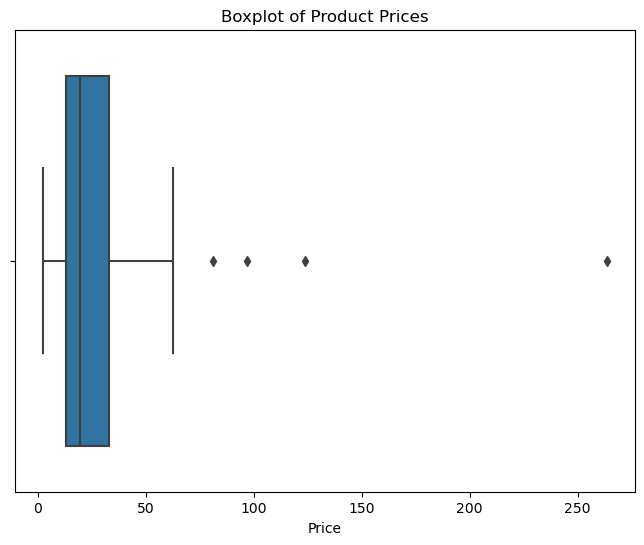

In [1084]:
plt.figure(figsize=(8, 6))
sns.boxplot(x=df_Products['Price'].dropna())  # استخدم dropna لإزالة القيم الفارغة
plt.title('Boxplot of Product Prices')
plt.xlabel('Price')
plt.show()

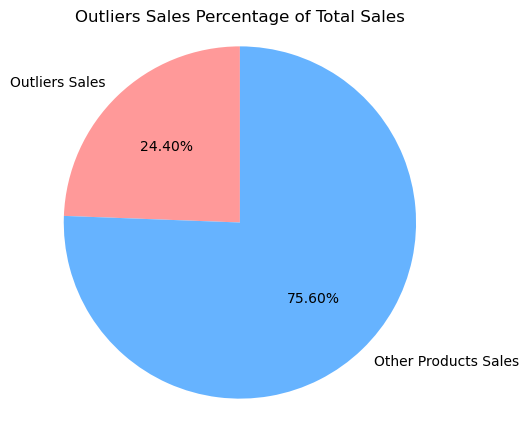


Total outliers sales: 94299.22
Total sales of all products: 386424.23000000004
Outliers sales percentage of total sales: 24.40%


In [1264]:
# تحقق من إجمالي مبيعات الأوتلايرز
total_sales_all_products = df_sales['TotalSales'].sum()
total_outliers_sales = df_outliers_total_sales['TotalSales'].sum()

# حساب نسبة مبيعات الأوتلايرز من إجمالي المبيعات الكلية
outliers_sales_percentage = (total_outliers_sales / total_sales_all_products) * 100

# تحقق من أن القيم صحيحة قبل رسم المخطط
if total_sales_all_products > 0 and total_outliers_sales > 0:
    # رسم المخطط الدائري (Pie Chart) للمبيعات
    labels = ['Outliers Sales', 'Other Products Sales']
    sizes = [total_outliers_sales, total_sales_all_products - total_outliers_sales]
    colors = ['#ff9999','#66b3ff']

    # رسم المخطط الدائري
    plt.figure(figsize=(5, 5))
    plt.pie(sizes, labels=labels, colors=colors, autopct='%1.2f%%', startangle=90)
    plt.title(f"Outliers Sales Percentage of Total Sales")
    plt.axis('equal')  # لنجعل المخطط دائري الشكل
    plt.show()
    
# طباعة النتائج
    print(f"\nTotal outliers sales: {total_outliers_sales}")
    print(f"Total sales of all products: {total_sales_all_products}")
    print(f"Outliers sales percentage of total sales: {outliers_sales_percentage:.2f}%")
else:
    print("There is an issue with the entered values, the chart cannot be drawn due to invalid values.")


The outlier products make up 24% of total sales, possibly due to the high price of the units sold. 
It's important to analyze these products and address any issues related to pricing or distribution to ensure sustainable performance.

## Display the products whose categories are 1, 3, and 6.

We presented all products in each category separately to better address the outliers. 
We compared the prices within each category to determine whether the high price is due to the quantity sold, 
a data entry error, or if the products are considered premium

###### Compare the prices of products in category 1, including those that are outliers:

In [966]:
# تصفية البيانات لعرض المنتجات التي تحتوي على CategoryID = 1
products_category_1 = df_Products[df_Products['CategoryID'] == 1]

# طباعة المنتجات التي تحتوي على CategoryID = 1
products_category_1


,ProductID,ProductName,SupplierID,CategoryID,Unit,Price
0,1,Chais,1,1,10 boxes x 20 bags,18.00
1,2,Chang,1,1,24 - 12 oz bottles,19.00
23,24,Guaraná Fantástica,10,1,12 - 355 ml cans,4.50
33,34,Sasquatch Ale,16,1,24 - 12 oz bottles,14.00
34,35,Steeleye Stout,16,1,24 - 12 oz bottles,18.00
37,38,Côte de Blaye,18,1,12 - 75 cl bottles,263.50
38,39,Chartreuse verte,18,1,750 cc per bottle,18.00
42,43,Ipoh Coffee,20,1,16 - 500 g tins,46.00
66,67,Laughing Lumberjack Lager,16,1,24 - 12 oz bottles,14.00
69,70,Outback Lager,7,1,24 - 355 ml bottles,15.00


###### Compare the prices of products in category 3, including those that are outliers:

In [968]:
# تصفية البيانات لعرض المنتجات التي تحتوي على CategoryID = 3
products_category_3 = df_Products[df_Products['CategoryID'] == 3]

# طباعة المنتجات التي تحتوي على CategoryID = 3
products_category_3


,ProductID,ProductName,SupplierID,CategoryID,Unit,Price
15,16,Pavlova,7,3,32 - 500 g boxes,17.45
18,19,Teatime Chocolate Biscuits,8,3,10 boxes x 12 pieces,9.20
19,20,Sir Rodney's Marmalade,8,3,30 gift boxes,81.00
20,21,Sir Rodney's Scones,8,3,24 pkgs. x 4 pieces,10.00
24,25,NuNuCa Nuß-Nougat-Creme,11,3,20 - 450 g glasses,14.00
25,26,Gumbär Gummibärchen,11,3,100 - 250 g bags,31.23
26,27,Schoggi Schokolade,11,3,100 - 100 g pieces,43.90
46,47,Zaanse koeken,22,3,10 - 4 oz boxes,9.50
47,48,Chocolade,22,3,10 pkgs.,12.75
48,49,Maxilaku,23,3,24 - 50 g pkgs.,20.00


###### Compare the prices of products in category 6, including those that are outliers:

In [1083]:
# تصفية البيانات لعرض المنتجات التي تحتوي على CategoryID = 6
products_category_6 = df_Products[df_Products['CategoryID'] == 6]

# طباعة المنتجات التي تحتوي على CategoryID = 6
products_category_6

,ProductID,ProductName,SupplierID,CategoryID,Unit,Price
8,9,Mishi Kobe Niku,4,6,18 - 500 g pkgs.,97.00
16,17,Alice Mutton,7,6,20 - 1 kg tins,39.00
28,29,Thüringer Rostbratwurst,12,6,50 bags x 30 sausgs.,123.79
52,53,Perth Pasties,24,6,48 pieces,32.80
53,54,Tourtière,25,6,16 pies,7.45
54,55,Pâté chinois,25,6,24 boxes x 2 pies,24.00


The products with higher prices have a large quantity sold, 
while the products with lower prices have fewer units sold.
These products have an excellent sales percentage of the total sales,
so we must give them attention due to their high price.

## Display the products with their units that have outlier prices sold:

In [1257]:
# 1. تحديد الأوتلايرز في جدول تفاصيل الطلبات بناءً على الأوتلايرز في جدول المبيعات
df_outliers_orders = df_OrderDetails[df_OrderDetails['ProductID'].isin(df_outliers_sales['ProductID'])]

# 2. حساب إجمالي المبيعات للأوتلايرز من جدول df_outliers_sales
df_outliers_total_sales = df_outliers_sales.groupby('ProductName')['TotalSales'].sum().reset_index()

# عرض النتائج النهائية
print("Outliers Summary (Total Sales Only):")
df_outliers_total_sales


Outliers Summary (Total Sales Only):


,ProductName,TotalSales
0,Côte de Blaye,62976.50
1,Mishi Kobe Niku,1940.00
2,Sir Rodney's Marmalade,8586.00
3,Thüringer Rostbratwurst,20796.72


C:\Users\LEGION\AppData\Local\Temp\ipykernel_17960\2727862266.py:14: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.



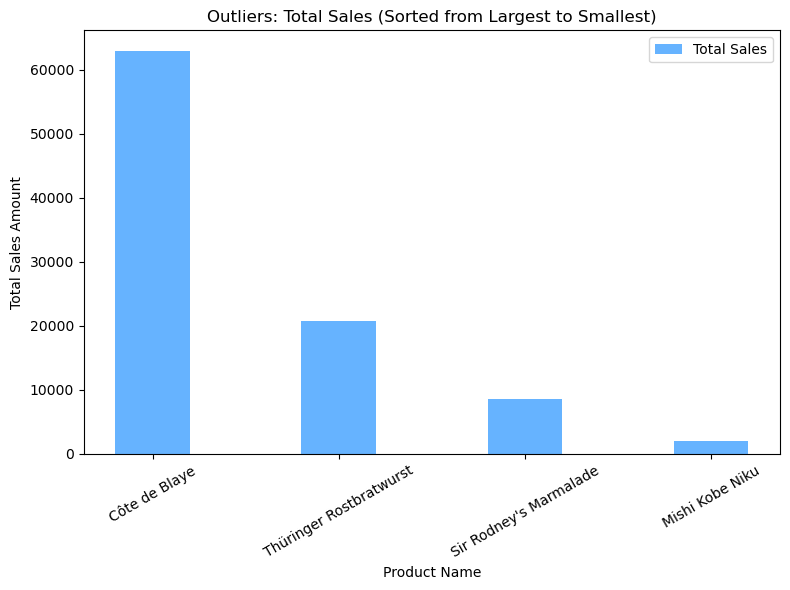

In [1258]:
# ترتيب البيانات حسب إجمالي المبيعات من الأكبر إلى الأصغر
df_outliers_total_sales_sorted = df_outliers_total_sales.sort_values(by='TotalSales', ascending=False)

# رسم مخطط شريطي لإجمالي المبيعات للأوتلايرز فقط (مرتبة من الأكبر إلى الأصغر)
fig, ax = plt.subplots(figsize=(8, 6))

# عرض إجمالي المبيعات كأشرطة
ax.bar(df_outliers_total_sales_sorted['ProductName'], df_outliers_total_sales_sorted['TotalSales'], width=0.4, label='Total Sales', color='#66b3ff')

# إضافة عنوان ووسوم
ax.set_title('Outliers: Total Sales (Sorted from Largest to Smallest)')
ax.set_xlabel('Product Name')
ax.set_ylabel('Total Sales Amount')
ax.set_xticklabels(df_outliers_total_sales_sorted['ProductName'], rotation=30)  # تدوير التسميات لسهولة القراءة
ax.legend()

# عرض المخطط
plt.tight_layout()
plt.show()


The products like Côte de Blaye achieved significantly higher sales, while Mishi Kobe Niku had much lower sales,
indicating a disparity in demand.
It is important to analyze influencing factors such as the season or promotional offers to understand these differences.

#### Attempt to identify the reason for the increase in sales of outlier products based on what is available to us:

In [1261]:
# 1. دمج بيانات الأوتلايرز مع تواريخ الأوامر للحصول على موسم كل منتج شاذ بناءً على OrderDate
outliers_with_order_details = pd.merge(df_outliers_orders, df_Orders[['OrderID', 'OrderDate']], on='OrderID', how='left')

# 2. تحويل عمود 'OrderDate' إلى نوع البيانات datetim
outliers_with_order_details['OrderDate'] = pd.to_datetime(outliers_with_order_details['OrderDate'], errors='coerce')

# 3. إضافة عمود 'Season' بناءً على شهر OrderDate
outliers_with_order_details['Season'] = outliers_with_order_details['OrderDate'].apply(
    lambda x: 'Winter' if x.month in [12, 1, 2] else 
    ('Spring' if x.month in [3, 4, 5] else 
     ('Summer' if x.month in [6, 7, 8] else 'Fall'))
)

# 4. دمج بيانات الأوتلايرز مع جدول المنتجات للحصول على سعر المنتج
outliers_with_products = pd.merge(outliers_with_order_details, df_Products[['ProductID', 'ProductName', 'Price']], on='ProductID', how='left')

# 5. حساب إجمالي المبيعات (Quantity * Price) لكل منتج
outliers_with_products['TotalSales'] = outliers_with_products['Quantity'] * outliers_with_products['Price']

# 6. تجميع النتائج حسب الموسم وحساب إجمالي المبيعات لكل موسم
outliers_season_sales = outliers_with_products.groupby(['Season'])['TotalSales'].sum().reset_index()

# 7. عرض النتائج النهائية حسب الموسم
print("Outliers Total Sales by Season:")
outliers_season_sales

Outliers Total Sales by Season:


,Season,TotalSales
0,Fall,34272.56
1,Summer,8440.75
2,Winter,51585.91


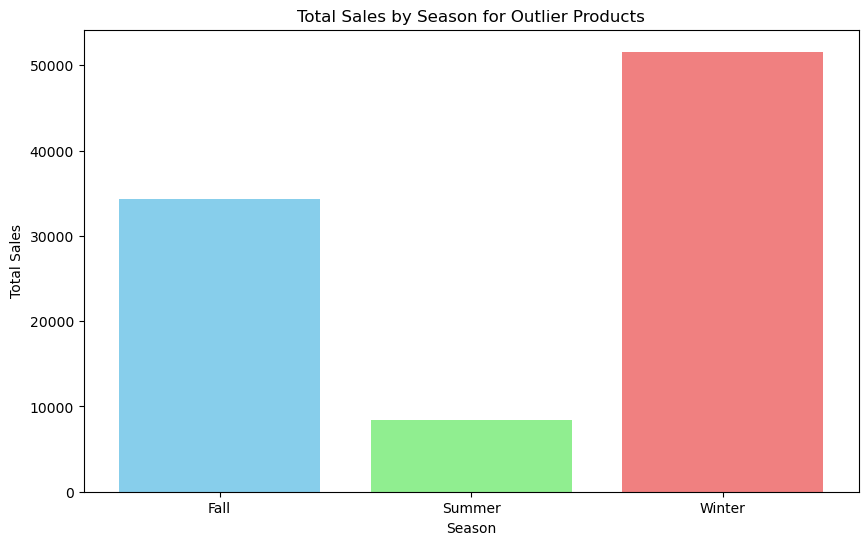

In [1262]:
plt.figure(figsize=(10, 6))
plt.bar(outliers_season_sales['Season'], outliers_season_sales['TotalSales'], color=['skyblue', 'lightgreen', 'lightcoral', 'lightskyblue'])
plt.title('Total Sales by Season for Outlier Products')
plt.xlabel('Season')
plt.ylabel('Total Sales')
plt.show()

The total sales of outliers by season show a clear trend:
    Winter has the highest sales at 51,585.91, followed by Fall at 34,272.56, and Summer at the lowest with 8,440.75.
    This suggests that certain outlier products perform significantly better in specific seasons, particularly in Winter,
    and this seasonal variation should be considered in further analysis or marketing strategies.

<a href="#toc" role="button" aria-pressed="true">🔝 Back to Table of Contents 🔝</a>

<a id="2.5.2"></a>
<h2>2.5.2 Outliers in Quantity</h2>

In [1087]:
df_OrderDetails['Quantity'].describe()

count    518.000000
mean      24.600386
std       18.376899
min        1.000000
25%       10.000000
50%       20.000000
75%       32.750000
max      120.000000
Name: Quantity, dtype: float64

In [1218]:
# حساب الربعيات (Q1 و Q3) لعمود Quantity
Q1 = df_OrderDetails['Quantity'].quantile(0.25)
Q3 = df_OrderDetails['Quantity'].quantile(0.75)
IQR = Q3 - Q1

# تحديد القيم الشاذة (Outliers) باستخدام قاعدة IQR
outliers = df_OrderDetails[(df_OrderDetails['Quantity'] < (Q1 - 1.5 * IQR)) | 
                           (df_OrderDetails['Quantity'] > (Q3 + 1.5 * IQR))]

# عرض عدد القيم الشاذة
print(f"Number of outliers: {len(outliers)}")

# عرض القيم الشاذة نفسها
outliers


Number of outliers: 22


,OrderDetailID,OrderID,ProductID,Quantity
53,54,10267,59,70
102,103,10286,35,100
183,184,10316,62,70
197,198,10324,35,70
200,201,10324,63,80
244,245,10339,17,70
259,260,10344,8,70
260,261,10345,8,70
261,262,10345,19,80
276,277,10351,44,77


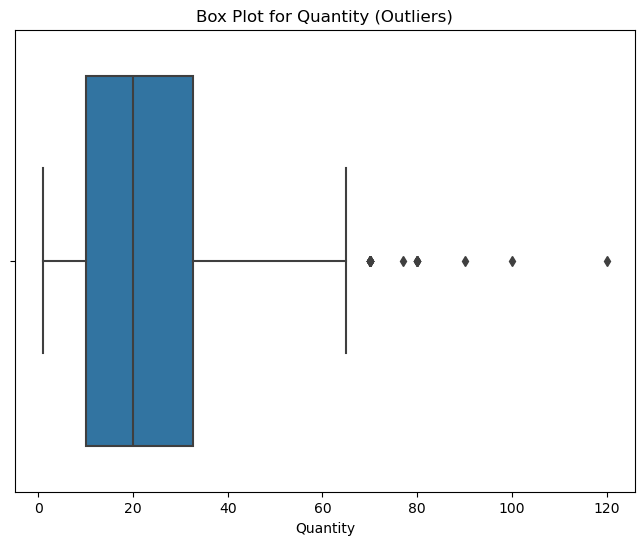

In [1219]:
# رسم مخطط Box Plot للعمود 'Quantity'
plt.figure(figsize=(8, 6))
sns.boxplot(x=df_OrderDetails['Quantity'])

# إضافة عنوان وتسمية المحاور
plt.title('Box Plot for Quantity (Outliers)')
plt.xlabel('Quantity')

# عرض المخطط
plt.show()


In [1220]:
# حساب الربعيات (Q1 و Q3) لعمود Quantity
Q1 = df_OrderDetails['Quantity'].quantile(0.25)
Q3 = df_OrderDetails['Quantity'].quantile(0.75)
IQR = Q3 - Q1

# تحديد القيم الشاذة (Outliers) باستخدام قاعدة IQR
outliers = df_OrderDetails[(df_OrderDetails['Quantity'] < (Q1 - 1.5 * IQR)) | 
                           (df_OrderDetails['Quantity'] > (Q3 + 1.5 * IQR))]

# تحديد القيم بدون القيم الشاذة
without_outliers = df_OrderDetails[~df_OrderDetails.index.isin(outliers.index)]

# حساب إجمالي الكميات
total_quantity = df_OrderDetails['Quantity'].sum()

# حساب إجمالي الكميات للقيم الشاذة (Outliers)
outliers_quantity = outliers['Quantity'].sum()

# حساب إجمالي الكميات للقيم بدون القيم الشاذة (Without Outliers)
without_outliers_quantity = without_outliers['Quantity'].sum()

# حساب النسب المئوية
percentage_outliers = (outliers_quantity / total_quantity) * 100
percentage_without_outliers = (without_outliers_quantity / total_quantity) * 100

# طباعة النتيجة
print(f"Total Quantity (All Data): {total_quantity}")
print(f"Total Quantity (Outliers): {outliers_quantity}")
print(f"Total Quantity (Without Outliers): {without_outliers_quantity}")
print(f"Percentage of Quantity from Outliers: {percentage_outliers:.2f}%")
print(f"Percentage of Quantity from Without Outliers: {percentage_without_outliers:.2f}%")


Total Quantity (All Data): 12743
Total Quantity (Outliers): 1697
Total Quantity (Without Outliers): 11046
Percentage of Quantity from Outliers: 13.32%
Percentage of Quantity from Without Outliers: 86.68%


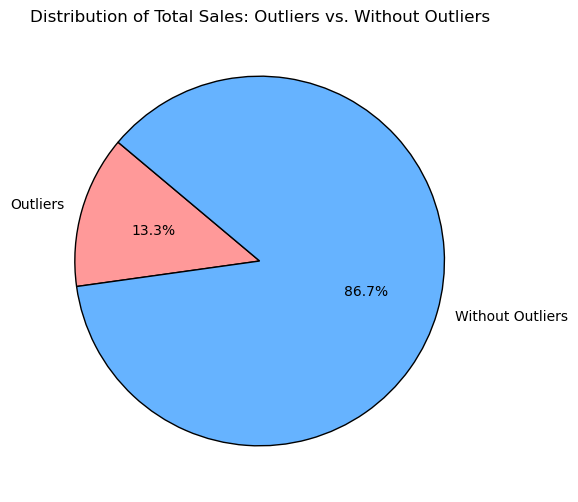

In [1244]:
# البيانات
labels = ['Outliers', 'Without Outliers']
sizes = [percentage_outliers, percentage_without_outliers]
colors = ['#ff9999','#66b3ff']  # اختيار ألوان مختلفة

# رسم المخطط
plt.figure(figsize=(6,6))
plt.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=140, wedgeprops={'edgecolor': 'black'})

# إضافة عنوان
plt.title('Distribution of Total Sales: Outliers vs. Without Outliers')

# عرض المخطط
plt.show()


The increase in outlier orders (13.32%) may reflect exceptional behavior, the impact of promotional campaigns, or seasonal factors.

## Display the products with their units that have outlier quantities sold:

In [1243]:
# دمج البيانات مع جدول المنتجات للحصول على اسم المنتج والوحدة
outliers_with_product = pd.merge(outliers, df_Products[['ProductID', 'ProductName', 'Unit']], on='ProductID', how='left')

# اختيار الأعمدة التي تحتوي على اسم المنتج والكمية والوحدة
outliers_with_product = outliers_with_product[['ProductName', 'Quantity', 'Unit']]

# عرض جدول القيم الشاذة مع أسماء المنتجات والوحدات والكميات
outliers_with_product


,ProductName,Quantity,Unit
0,Raclette Courdavault,70,5 kg pkg.
1,Steeleye Stout,100,24 - 12 oz bottles
2,Tarte au sucre,70,48 pies
3,Steeleye Stout,70,24 - 12 oz bottles
4,Vegie-spread,80,15 - 625 g jars
5,Alice Mutton,70,20 - 1 kg tins
6,Northwoods Cranberry Sauce,70,12 - 12 oz jars
7,Northwoods Cranberry Sauce,70,12 - 12 oz jars
8,Teatime Chocolate Biscuits,80,10 boxes x 12 pieces
9,Gula Malacca,77,20 - 2 kg bags


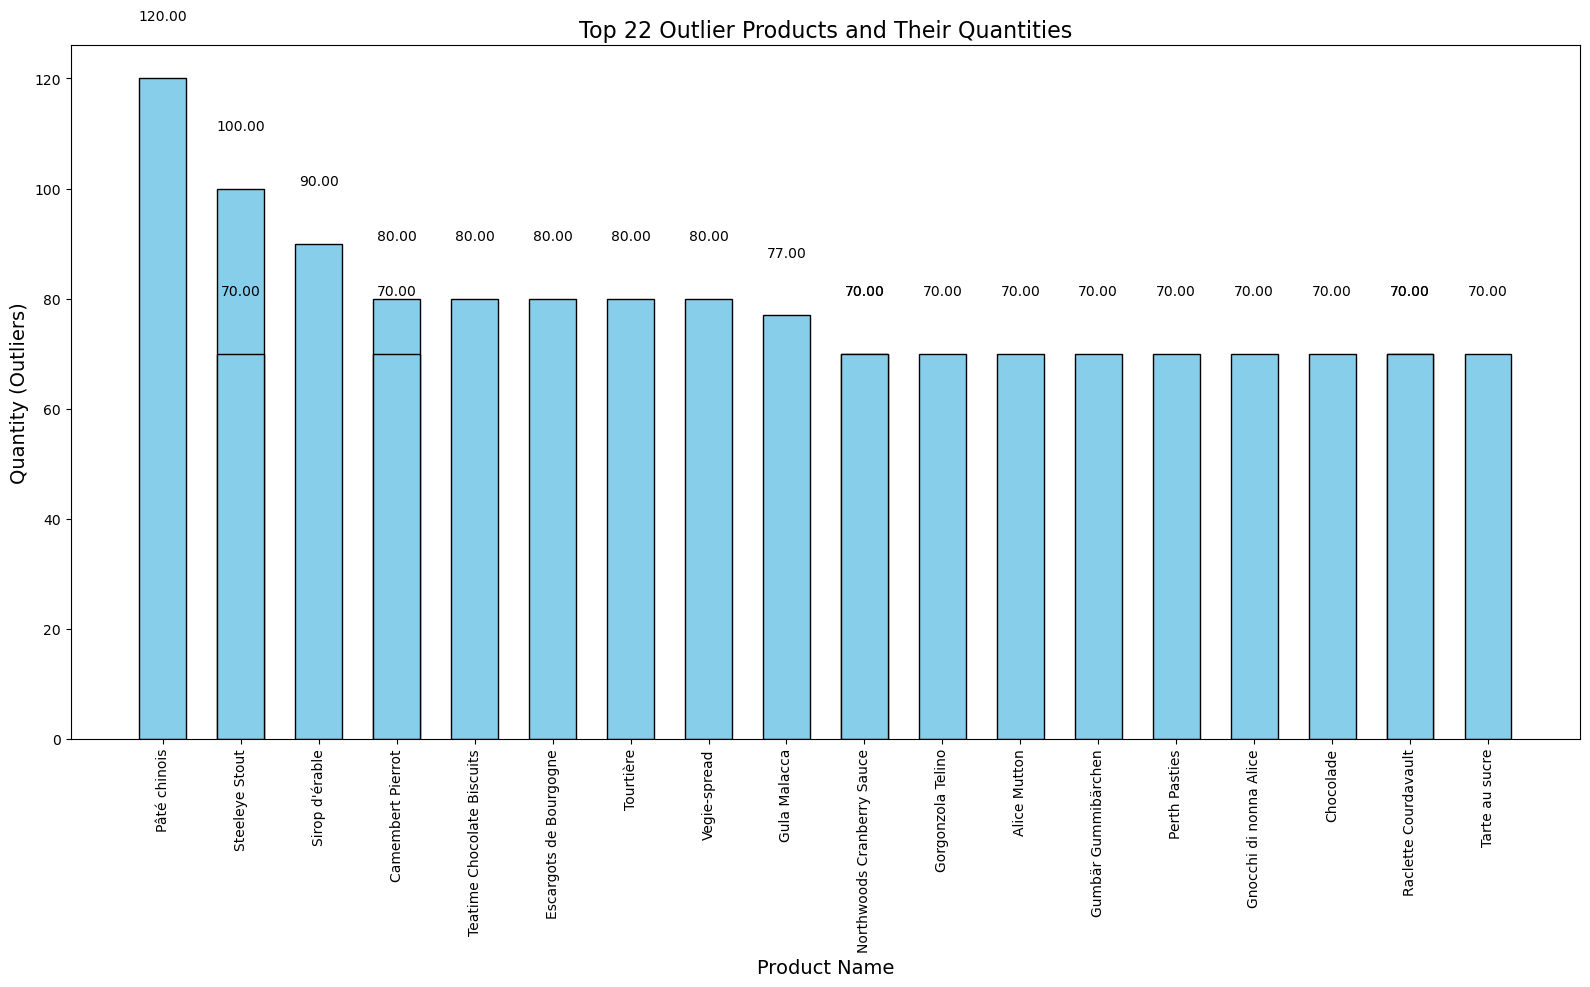

In [1227]:
# دمج القيم الشاذة مع اسم المنتج ووحدة القياس
outliers_with_product = pd.merge(outliers, df_Products[['ProductID', 'ProductName']], on='ProductID', how='left')

# ترتيب المنتجات حسب الكمية بشكل تنازلي
outliers_with_product_sorted = outliers_with_product.sort_values(by='Quantity', ascending=False)

# اختيار أول 22 منتج شاذ
outliers_with_product_top_22 = outliers_with_product_sorted.head(22)

# رسم المخطط للأسماء والكميات الشاذة
plt.figure(figsize=(16, 10))  # تكبير حجم الصورة

# رسم الأعمدة باستخدام bar و زيادة العرض والتباعد
bars = plt.bar(outliers_with_product_top_22['ProductName'], 
               outliers_with_product_top_22['Quantity'], 
               color='skyblue', 
               edgecolor='black', width=0.6)

# إضافة الأرقام داخل الأعمدة
for bar in bars:
    yval = bar.get_height()  # الحصول على ارتفاع الشريط (القيمة)
    plt.text(bar.get_x() + bar.get_width() / 2, yval + 10, f'{yval:.2f}', ha='center', va='bottom', fontsize=10, color='black')

# تخصيص المحاور
plt.xlabel('Product Name', fontsize=14)
plt.ylabel('Quantity (Outliers)', fontsize=14)
plt.title('Top 22 Outlier Products and Their Quantities', fontsize=16)

# تدوير تسميات المحور X لسهولة القراءة
plt.xticks(rotation=90, fontsize=10)

# تحسين التنسيق للمخطط (التأكد من أنه لا توجد تسميات متداخلة)
plt.tight_layout()

# عرض المخطط
plt.show()


The increased demand for these products may be due to promotional campaigns, special seasons, 
or changes in market preferences.
It is important to review purchase dates, promotions, and customer feedback to understand the exact reason.

#### Attempt to identify the reason for the increased demand for outlier products based on the available data:

In [1239]:
# دمج البيانات مع جدول الأوامر للحصول على OrderDate
order_details_with_orders = pd.merge(outliers, df_Orders[['OrderID', 'OrderDate']], on='OrderID', how='left')

# دمج مع جدول المنتجات للحصول على اسم المنتج والوحدة
outliers_with_product = pd.merge(order_details_with_orders, df_Products[['ProductID', 'ProductName', 'Unit']], on='ProductID', how='left')

# اختيار الأعمدة التي تحتوي على اسم المنتج والكمية والوحدة
outliers_with_product = outliers_with_product[['ProductName', 'Quantity', 'Unit', 'OrderDate']]

# تحويل عمود OrderDate إلى نوع البيانات datetime
outliers_with_product['OrderDate'] = pd.to_datetime(outliers_with_product['OrderDate'])

# دالة لتحديد الموسم بناءً على الشهر
def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Fall'

# إضافة الموسم بناءً على الشهر في OrderDate
outliers_with_product['Season'] = outliers_with_product['OrderDate'].dt.month.apply(get_season)

# عرض النتائج مع الموسم
outliers_with_product = outliers_with_product[['ProductName', 'Quantity', 'Unit', 'Season']]

# عرض الجدول النهائي
outliers_with_product


,ProductName,Quantity,Unit,Season
0,Raclette Courdavault,70,5 kg pkg.,Summer
1,Steeleye Stout,100,24 - 12 oz bottles,Summer
2,Tarte au sucre,70,48 pies,Fall
3,Steeleye Stout,70,24 - 12 oz bottles,Fall
4,Vegie-spread,80,15 - 625 g jars,Fall
5,Alice Mutton,70,20 - 1 kg tins,Fall
6,Northwoods Cranberry Sauce,70,12 - 12 oz jars,Fall
7,Northwoods Cranberry Sauce,70,12 - 12 oz jars,Fall
8,Teatime Chocolate Biscuits,80,10 boxes x 12 pieces,Fall
9,Gula Malacca,77,20 - 2 kg bags,Fall


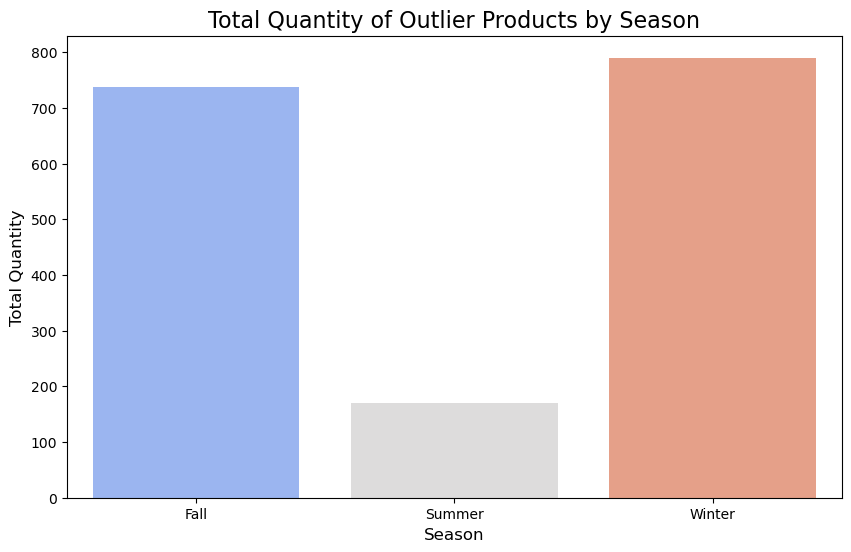

In [1240]:
# تجميع البيانات حسب الموسم
seasonal_data = outliers_with_product.groupby('Season').agg(
    Total_Quantity=('Quantity', 'sum')
).reset_index()

# رسم المخطط
plt.figure(figsize=(10, 6))
sns.barplot(x='Season', y='Total_Quantity', data=seasonal_data, palette='coolwarm')

# إضافة العناوين والتسميات
plt.title('Total Quantity of Outlier Products by Season', fontsize=16)
plt.xlabel('Season', fontsize=12)
plt.ylabel('Total Quantity', fontsize=12)

# عرض المخطط
plt.show()


Seasonality could explain the increased demand for certain products,
especially in seasons that call for warm or specialty foods like winter and fall.
Therefore, this increase in quantities could be part of a natural demand pattern tied to the season,
but other factors such as promotions or price changes should also be considered.

<a href="#toc" role="button" aria-pressed="true">🔝 Back to Table of Contents 🔝</a>

<a id="2.6"></a>
## <b>2.6 <span style='color:#F1A424'>the Categorical Columns</span></b>

<a id="2.6.1"></a>
<h2>2.6.1 Handling the OrderDate column and convert it to the datetime type</h2>

We converted the OrderDate column to datetime type to extract the year and month for proper time-based sales analysis. This helps in organizing and filtering the data, making it easier to analyze trends across months or years.

In [1092]:
# تحويل 'OrderDate' إلى datetime
df_Orders['OrderDate'] = pd.to_datetime(df_Orders['OrderDate'])

# استخراج السنة والشهر كاسم الشهر وتحويلهما إلى نص
df_Orders['Year'] = df_Orders['OrderDate'].dt.year.astype(str)  # السنة بصيغة نصية
df_Orders['Month'] = df_Orders['OrderDate'].dt.month_name()  # اسم الشهر بصيغة نصية

# عرض النتيجة للتأكد من أن الأعمدة تم إضافتها بشكل صحيح
df_Orders[['OrderDate', 'Year', 'Month']].head()


,OrderDate,Year,Month
0,1996-07-04,1996,July
1,1996-07-05,1996,July
2,1996-07-08,1996,July
3,1996-07-08,1996,July
4,1996-07-09,1996,July


<a href="#toc" role="button" aria-pressed="true">🔝 Back to Table of Contents 🔝</a>

<a id="2.6.2"></a>
<h2>2.6.2 Adding a Season Column</h2>

Adding the Season column helps categorize each month into seasons (Spring, Summer, Fall, Winter), which makes it easier to analyze sales trends based on seasons. This classification aids in identifying seasonal patterns and adjusting marketing or sales strategies accordingly.

In [1093]:
# دالة لتصنيف الأشهر حسب الفصول
def get_season(month):
    if month in [3, 4, 5]:
        return 'Spring'  # الربيع
    elif month in [6, 7, 8]:
        return 'Summer'  # الصيف
    elif month in [9, 10, 11]:
        return 'Fall'    # الخريف
    else:
        return 'Winter'  # الشتاء

# تطبيق الدالة على العمود 'Month' لتصنيف الأشهر
df_Orders['Season'] = df_Orders['OrderDate'].dt.month.apply(get_season)

# تحويل العمود 'Season' إلى نوع بيانات تصنيفي (Categorical)
df_Orders['Season'] = pd.Categorical(df_Orders['Season'], categories=['Winter', 'Spring', 'Summer', 'Fall'], ordered=True)

# عرض النتائج
df_Orders[['OrderDate', 'Month', 'Season']].head()

,OrderDate,Month,Season
0,1996-07-04,July,Summer
1,1996-07-05,July,Summer
2,1996-07-08,July,Summer
3,1996-07-08,July,Summer
4,1996-07-09,July,Summer


<a href="#toc" role="button" aria-pressed="true">🔝 Back to Table of Contents 🔝</a>

<a id="2.6.3"></a>
<h2>2.6.3 Merge the two columns to create a single column named Employee Name</h2>

In [1094]:
# دمج الأعمدة 'FirstName' و 'LastName' في عمود جديد يسمى 'EmployeeName'
df_Employees['EmployeeName'] = df_Employees['FirstName'].fillna('') + ' ' + df_Employees['LastName'].fillna('')

# حذف الأعمدة 'FirstName' و 'LastName' بعد دمجهما
df_Employees = df_Employees.drop(['FirstName', 'LastName'], axis=1)

# عرض النتيجة
df_Employees


,EmployeeID,BirthDate,Photo,Notes,EmployeeName
0,1,12/8/1968,EmpID1.pic,Education includes a BA in psychology from Col...,Nancy Davolio
1,2,2/19/1952,EmpID2.pic,Andrew received his BTS commercial and a Ph.D....,Andrew Fuller
2,3,8/30/1963,EmpID3.pic,Janet has a BS degree in chemistry from Boston...,Janet Leverling
3,4,9/19/1958,EmpID4.pic,Margaret holds a BA in English literature from...,Margaret Peacock
4,5,3/4/1955,EmpID5.pic,Steven Buchanan graduated from St. Andrews Uni...,Steven Buchanan
5,6,7/2/1963,EmpID6.pic,Michael is a graduate of Sussex University (MA...,Michael Suyama
6,7,5/29/1960,EmpID7.pic,Robert King served in the Peace Corps and trav...,Robert King
7,8,1/9/1958,EmpID8.pic,Laura received a BA in psychology from the Uni...,Laura Callahan
8,9,7/2/1969,EmpID9.pic,Anne has a BA degree in English from St. Lawre...,Anne Dodsworth
9,10,9/19/1928,EmpID10.pic,An old chum,Adam West


<a href="#toc" role="button" aria-pressed="true">🔝 Back to Table of Contents 🔝</a>

<a id="2.7"></a>
## <b>2.7 <span style='color:#F1A424'>the Numerical Columns</span></b>

<a id="2.7.1"></a>
<h2>2.7.1 Adding a new column named Total Sales</h2>

The reason for adding the TotalSales column is to calculate the total revenue for each order by multiplying the Quantity of items ordered with the Price of each product. This helps in financial analysis, reporting, and decision-making regarding inventory, pricing, and sales strategies.

In [23]:
# دمج بيانات OrderDetails مع Products للحصول على السعر
df_merged = pd.merge(df_OrderDetails, df_Products[['ProductID', 'Price']], on='ProductID', how='left')

# حساب إجمالي المبيعات (Quantity * Price) لكل منتج في الطلب
df_merged['Total Sales'] = df_merged['Quantity'] * df_merged['Price']

# تجميع البيانات حسب OrderID لحساب إجمالي المبيعات لكل طلب
order_sales = df_merged.groupby('OrderID').agg(
    Total_Sales=('Total Sales', 'sum')  # إجمالي المبيعات لكل طلب
).reset_index()

# دمج إجمالي المبيعات مع جدول الأوامر (Orders)
df_Orders['Total Sales'] = df_Orders['OrderID'].map(order_sales.set_index('OrderID')['Total_Sales'])

# ملء القيم المفقودة بـ 0 (إذا كان هناك أي NaN في Total Sales)
df_Orders['Total Sales'] = df_Orders['Total Sales'].fillna(0)

# عرض الجدول النهائي مع إجمالي المبيعات لكل طلب
df_Orders[['OrderID', 'Total Sales']].head()


,OrderID,Total Sales
0,10248,566.00
1,10249,2329.25
2,10250,2267.25
3,10251,839.50
4,10252,4662.50


<a href="#toc" role="button" aria-pressed="true">🔝 Back to Table of Contents 🔝</a>

<a id="2.7.2"></a>
<h2>2.7.2 Adding two columns to the Customers table (Total_Orders, Total_Spent)</h2>

Calculating Total Orders and Total Spent for each customer helps businesses understand customer engagement and value. Total Orders indicates how frequently a customer purchases, while Total Spent reveals their overall contribution to revenue, enabling personalized marketing and targeted retention strategies.

In [1096]:
# 1. دمج بيانات OrderDetails مع Orders بناءً على OrderID
df_merged = pd.merge(df_Orders, df_OrderDetails, on='OrderID', how='inner')

# 2. دمج بيانات Products مع df_merged بناءً على ProductID للحصول على عمود Price
df_merged = pd.merge(df_merged, df_Products[['ProductID', 'Price']], on='ProductID', how='inner')

# 3. حساب إجمالي المبيعات (Quantity * Price)
df_merged['Total Sales'] = df_merged['Quantity'] * df_merged['Price']

# 4. حساب إجمالي الطلبات (Total Orders) و إجمالي الإنفاق (Total Spent) لكل عميل
customer_summary = df_merged.groupby('CustomerID').agg(
    total_orders=('OrderID', 'nunique'),  # عدد الطلبات الفريدة لكل عميل
    total_spent=('Total Sales', 'sum')  # مجموع إجمالي المبيعات لكل عميل
).reset_index()

# 5. دمج إجمالي الطلبات وإجمالي الإنفاق مع جدول العملاء (Customers)
# نستخدم suffixes لتجنب أي تضارب في الأعمدة المتشابهة
df_Customers = pd.merge(df_Customers, customer_summary, on='CustomerID', how='left', suffixes=('', '_summary'))

# 6. ملء القيم المفقودة في إجمالي الطلبات (Total_Orders) و إجمالي المبيعات (Total_Sales) بـ 0
df_Customers['total_orders'] = df_Customers['total_orders'].fillna(0).astype(int)
df_Customers['total_spent'] = df_Customers['total_spent'].fillna(0)

# 7. عرض الجدول النهائي مع إجمالي الطلبات وإجمالي الإنفاق لكل عميل
df_Customers[['CustomerID', 'CustomerName', 'total_orders', 'total_spent']].head()


,CustomerID,CustomerName,total_orders,total_spent
0,1,Alfreds Futterkiste,0,0.00
1,2,Ana Trujillo Emparedados y helados,1,111.00
2,3,Antonio Moreno Taquería,1,504.00
3,4,Around the Horn,2,1723.75
4,5,Berglunds snabbköp,3,5406.90


<a href="#toc" role="button" aria-pressed="true">🔝 Back to Table of Contents 🔝</a>

<a id="2.7.2"></a>
<h2>2.7.2 Adding two columns to the Employees table (Total_Orders, Total_Spent)</h2>

Calculating Total Orders and Total Sales for each employee helps assess their performance and evaluate their results. Total Orders reflects the volume of work the employee has processed, through the number of orders handled, while Total Sales shows the monetary value generated by the employee through sales. This analysis helps in identifying top-performing employees, and it also aids in making decisions related to training, rewards, and motivation.

In [1097]:
# 1. دمج بيانات OrderDetails مع Orders بناءً على OrderID
df_merged = pd.merge(df_Orders, df_OrderDetails, on='OrderID', how='inner')

# 2. دمج بيانات Products مع df_merged بناءً على ProductID للحصول على عمود Price
df_merged = pd.merge(df_merged, df_Products[['ProductID', 'Price']], on='ProductID', how='inner')

# 3. حساب إجمالي المبيعات (Quantity * Price)
df_merged['Total Sales'] = df_merged['Quantity'] * df_merged['Price']

# 4. حساب إجمالي الطلبات (Total Orders) و إجمالي المبيعات (Total Sales) لكل موظف
employee_summary = df_merged.groupby('EmployeeID').agg(
    total_orders=('OrderID', 'nunique'),  # عدد الطلبات الفريدة لكل موظف
    total_sales=('Total Sales', 'sum')  # مجموع إجمالي المبيعات لكل موظف
).reset_index()

# 5. دمج إجمالي الطلبات وإجمالي المبيعات مع جدول الموظفين (Employees)
df_Employees = pd.merge(df_Employees, employee_summary, on='EmployeeID', how='left', suffixes=('', '_summary'))

# 6. ملء القيم المفقودة في إجمالي الطلبات (Total_Orders) و إجمالي المبيعات (Total_Sales) بـ 0
df_Employees['total_orders'] = df_Employees['total_orders'].fillna(0).astype(int)
df_Employees['total_sales'] = df_Employees['total_sales'].fillna(0)

# 7. عرض الجدول النهائي مع إجمالي الطلبات وإجمالي المبيعات لكل موظف
df_Employees[['EmployeeName', 'total_orders', 'total_sales']]


,EmployeeName,total_orders,total_sales
0,Nancy Davolio,29,57690.39
1,Andrew Fuller,20,32503.16
2,Janet Leverling,31,42838.35
3,Margaret Peacock,40,105696.50
4,Steven Buchanan,11,27480.80
5,Michael Suyama,18,25399.25
6,Robert King,14,39772.30
7,Laura Callahan,27,39309.38
8,Anne Dodsworth,6,15734.10
9,Adam West,0,0.00


<a href="#toc" role="button" aria-pressed="true">🔝 Back to Table of Contents 🔝</a>

<a id="2.7.3"></a>
<h2>2.7.3 Adding a new Column named Available</h2>

The goal of this process is to extract the available units in stock for each product
and convert it into a numeric value, making it easier to perform accurate analysis 
or calculations on the inventory.

In [24]:
# استخراج القيم الفريدة في عمود 'UnitPrice' في جدول df_Products
unique_values = df_Products['Unit'].unique()

# عرض القيم الفريدة
unique_values


array(['10 boxes x 20 bags', '24 - 12 oz bottles', '12 - 550 ml bottles',
       '48 - 6 oz jars', '36 boxes', '12 - 8 oz jars', '12 - 1 lb pkgs.',
       '12 - 12 oz jars', '18 - 500 g pkgs.', '12 - 200 ml jars',
       '1 kg pkg.', '10 - 500 g pkgs.', '2 kg box', '40 - 100 g pkgs.',
       '24 - 250 ml bottles', '32 - 500 g boxes', '20 - 1 kg tins',
       '16 kg pkg.', '10 boxes x 12 pieces', '30 gift boxes',
       '24 pkgs. x 4 pieces', '24 - 500 g pkgs.', '12 - 250 g pkgs.',
       '12 - 355 ml cans', '20 - 450 g glasses', '100 - 250 g bags',
       '100 - 100 g pieces', '25 - 825 g cans', '50 bags x 30 sausgs.',
       '10 - 200 g glasses', '12 - 100 g pkgs', '24 - 200 g pkgs.',
       '500 g', '24 - 250 g jars', '12 - 500 g pkgs.',
       '12 - 75 cl bottles', '750 cc per bottle', '24 - 4 oz tins',
       '12 - 12 oz cans', '32 - 1 kg pkgs.', '16 - 500 g tins',
       '20 - 2 kg bags', '1k pkg.', '4 - 450 g glasses',
       '10 - 4 oz boxes', '10 pkgs.', '24 - 50 g pkgs.',
    

#### We had to add the number one next to the sold unit to be consistent with the other units:

In [1099]:
df_Products[df_Products['Unit'] == '500 ml']

,ProductID,ProductName,SupplierID,CategoryID,Unit,Price
75,76,Lakkalikööri,23,1,500 ml,18.0


In [1100]:
# استبدال 500 ml بـ 1 - 500 ml
df_Products.loc[df_Products['Unit'] == '500 ml', 'Unit'] = '1 - 500 ml'

# التحقق من التعديل
df_Products[df_Products['Unit'] == '1 - 500 ml']

,ProductID,ProductName,SupplierID,CategoryID,Unit,Price
75,76,Lakkalikööri,23,1,1 - 500 ml,18.0


In [1101]:
# استخراج الرقم الأول من عمود Unit باستخدام Regular Expression
df_Products['Available'] = df_Products['Unit'].str.extract(r'(\d+)').astype(int)

# عرض النتيجة
df_Products[['Unit','Available']]

,Unit,Available
0,10 boxes x 20 bags,10
1,24 - 12 oz bottles,24
2,12 - 550 ml bottles,12
3,48 - 6 oz jars,48
4,36 boxes,36
...,...,...
72,24 - 150 g jars,24
73,5 kg pkg.,5
74,24 - 0.5 l bottles,24
75,1 - 500 ml,1


<a href="#toc" role="button" aria-pressed="true">🔝 Back to Table of Contents 🔝</a>

<a id="2.7.4"></a>
<h2>2.7.4 Adding PriceSegment Column and Chart for Distribution</h2>

Adding the PriceSegment column helps classify products based on price into categories like Low, Mid, and High, making data analysis easier and improving marketing strategies and inventory management. It also helps identify the best-performing segments for better decision-making.

In [1102]:
# تحديد دالة لتصنيف الأسعار حسب النطاق الجديد
def classify_price(price):
    if price >= 2 and price <= 20:
        return 'Low'    # الفئة المنخفضة
    elif 21 <= price <= 42:
        return 'Mid'    # الفئة المتوسطة
    elif 43 <= price <= 63:
        return 'High'   # الفئة المرتفعة
    else:
        return 'Out of Range'  # إذا كان السعر خارج النطاق المحدد

# تطبيق التصنيف على عمود 'Price' وإضافة العمود 'PriceSegment'
df_Products['PriceSegment'] = df_Products['Price'].apply(classify_price)

# عرض النتائج مع العمود الجديد 'PriceSegment'
df_Products[['Price', 'PriceSegment']]


,Price,PriceSegment
0,18.00,Low
1,19.00,Low
2,10.00,Low
3,22.00,Mid
4,21.35,Mid
...,...,...
72,15.00,Low
73,10.00,Low
74,7.75,Low
75,18.00,Low


#### Number of products in each price segment

In [1103]:
# حساب عدد المنتجات داخل كل فئة سعرية
product_count_by_segment = df_Products.groupby('PriceSegment').size().reset_index(name='Product Count')

# عرض النتائج
product_count_by_segment

,PriceSegment,Product Count
0,High,8
1,Low,40
2,Mid,25
3,Out of Range,4


In [1104]:
import plotly.express as px

# حساب عدد المنتجات داخل كل فئة سعرية
product_count_by_segment = df_Products.groupby('PriceSegment').size().reset_index(name='Product Count')

# إنشاء المخطط الشريطي
fig = px.bar(product_count_by_segment, 
             x='PriceSegment', 
             y='Product Count', 
             title='Product Distribution by Price Segment',  # العنوان بالإنجليزية
             labels={'PriceSegment': 'Price Segment', 'Product Count': 'Product Count'},  # تسميات المحاور بالإنجليزية
             color='PriceSegment')

# عرض المخطط
fig.show()


<a href="#toc" role="button" aria-pressed="true">🔝 Back to Table of Contents 🔝</a>

<a id="2.7.6"></a>
<h2>2.7.6 Adding a new column named Product_Count on Suppliers Table and Chart for Distribution</h2>

Distribution of products supplied by suppliers and determining the number of products each supplier provides. This helps in comparing suppliers and identifying those supplying the highest or lowest number of products.

In [1105]:
# دمج بيانات OrderDetails مع بيانات المنتجات للحصول على معلومات المورد
order_details_with_supplier = pd.merge(df_OrderDetails, df_Products[['ProductID', 'SupplierID']], on='ProductID', how='left')

# دمج بيانات الموردين للحصول على SupplierName
order_details_with_supplier = pd.merge(order_details_with_supplier, df_Suppliers[['SupplierID', 'SupplierName']], on='SupplierID', how='left')

# تجميع البيانات حسب SupplierName لحساب عدد المنتجات المميزة لكل مورد
supplier_product_count = order_details_with_supplier.groupby('SupplierName')['ProductID'].nunique().reset_index(name='Product_Count')

# دمج مع جدول الموردين لإضافة عمود Product_Count في جدول الموردين
df_Suppliers = pd.merge(df_Suppliers, supplier_product_count, on='SupplierName', how='left')

# عرض النتائج
df_Suppliers[['SupplierName', 'Product_Count']]


,SupplierName,Product_Count
0,Exotic Liquid,3
1,New Orleans Cajun Delights,4
2,Grandma Kelly's Homestead,3
3,Tokyo Traders,3
4,Cooperativa de Quesos 'Las Cabras',2
5,Mayumi's,3
6,"Pavlova, Ltd.",5
7,"Specialty Biscuits, Ltd.",4
8,PB Knäckebröd AB,2
9,Refrescos Americanas LTDA,1


#### Number products per Supplier

In [1106]:
# ترتيب الموردين حسب عدد المنتجات المميزة من الأكبر إلى الأصغر
df_Suppliers_sorted = df_Suppliers.sort_values(by='Product_Count', ascending=False)

# إنشاء المخطط الشريطي لعدد المنتجات المميزة لكل مورد بعد الترتيب
fig = px.bar(df_Suppliers_sorted, 
             x='SupplierName', 
             y='Product_Count', 
             title='Number of Unique Products per Supplier (Sorted)',  # العنوان بالإنجليزية
             labels={'SupplierName': 'Supplier Name', 'Product_Count': 'Product Count'},  # تسميات المحاور بالإنجليزية
             color='Product_Count',  # تلوين الأعمدة بناءً على عدد المنتجات
             color_continuous_scale='Viridis')

# عرض المخطط
fig.show()


<a href="#toc" role="button" aria-pressed="true">🔝 Back to Table of Contents 🔝</a>

<a id="2.7.7"></a>
<h2>2.7.7 Adding a new column named TotalOrders on Shippers Table and Chart for Distribution </h2>

Distribution of orders handled by shipping companies and determining the number of orders each company processes. This helps in comparing shipping companies and identifying those handling the highest or lowest number of orders.

In [1107]:
# 1. حساب إجمالي عدد الطلبات لكل شركة شحن من جدول الطلبات (df_Orders)
orders_per_shipper = df_Orders.groupby('ShipperID')['OrderID'].count().reset_index()

# 2. إعادة تسمية الأعمدة لتوضيح البيانات
orders_per_shipper.columns = ['ShipperID', 'TotalOrders']

# 3. دمج عدد الطلبات مع جدول شركات الشحن (df_Shippers)
df_Shippers = pd.merge(df_Shippers, orders_per_shipper, on='ShipperID', how='left')

# 4.عرض النتيجة
df_Shippers[['ShipperID', 'ShipperName', 'TotalOrders']]


,ShipperID,ShipperName,TotalOrders
0,1,Speedy Express,54
1,2,United Package,74
2,3,Federal Shipping,68


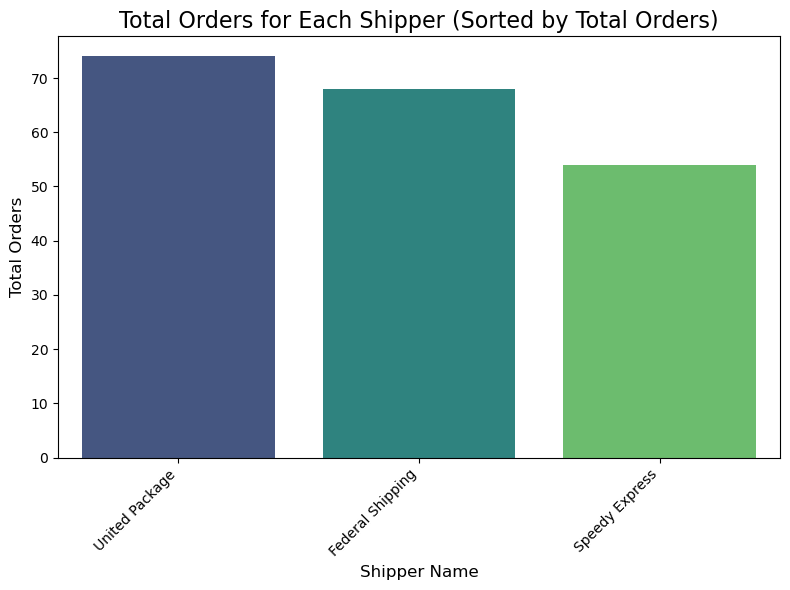

In [1108]:
# 1. Ensure the data contains the correct 'TotalOrders' and 'ShipperName' columns
# If you've already merged the data, make sure df_Shippers contains the appropriate columns

# 2. Sort the data based on 'TotalOrders' in descending order
df_Shippers_sorted = df_Shippers.sort_values(by='TotalOrders', ascending=False)

# 3. Create a bar plot with sorted data
plt.figure(figsize=(8, 6))  # Set the size of the plot
sns.barplot(x='ShipperName', y='TotalOrders', data=df_Shippers_sorted, palette='viridis')

# 4. Customize the plot
plt.title('Total Orders for Each Shipper (Sorted by Total Orders)', fontsize=16)  # Add a title
plt.xlabel('Shipper Name', fontsize=12)  # Label for the X-axis
plt.ylabel('Total Orders', fontsize=12)  # Label for the Y-axis

# Rotate the x-axis labels for better readability
plt.xticks(rotation=45, ha='right')

# 5. Show the plot
plt.tight_layout()  # Adjust the plot to fit the layout properly
plt.show()


<a href="#toc" role="button" aria-pressed="true">🔝 Back to Table of Contents 🔝</a>

# <a id="3"></a>
## <b>3 <span style='color:#F1A424'>Exploring and Visualizing</span></b>

# <a id="3.1"></a>
## <b>3.1 <span style='color:#F1A424'>Top 10 Customers: Number of Orders and Total Spent($)</span></b>

C:\Users\LEGION\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning:

use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.

C:\Users\LEGION\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning:

use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.



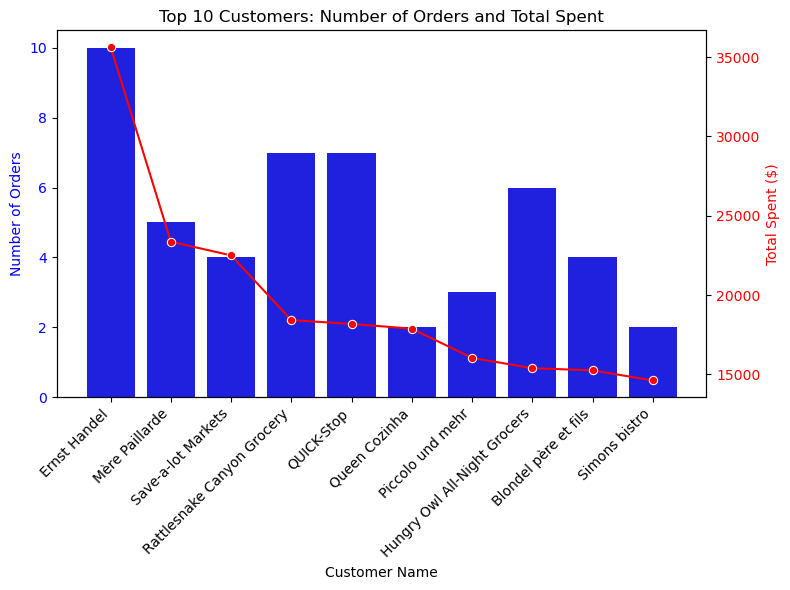

In [1109]:
# 1. أخذ أول 10 عملاء بناءً على إجمالي الإنفاق وترتيبهم من الأكبر إلى الأصغر حسب total_spent
top_10_customers = df_Customers[['CustomerID', 'CustomerName', 'total_orders', 'total_spent']].sort_values(by='total_spent', ascending=False).head(10)

# 2. رسم بياني يعرض عدد الطلبات وإجمالي الإنفاق لكل من أول 10 عملاء
fig, ax1 = plt.subplots(figsize=(8, 6))

# رسم عدد الطلبات
sns.barplot(x='CustomerName', y='total_orders', data=top_10_customers, color='b', ax=ax1)
ax1.set_xlabel('Customer Name')
ax1.set_ylabel('Number of Orders', color='b')
ax1.tick_params(axis='y', labelcolor='b')
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')

# إضافة المحور الثاني لإجمالي الإنفاق
ax2 = ax1.twinx()
sns.lineplot(x='CustomerName', y='total_spent', data=top_10_customers, color='r', marker='o', ax=ax2)
ax2.set_ylabel('Total Spent ($)', color='r')
ax2.tick_params(axis='y', labelcolor='r')

# عرض الرسم البياني
plt.title('Top 10 Customers: Number of Orders and Total Spent')
plt.tight_layout()
plt.show()


The plot shows the relationship between the number of orders and total spending for the top 10 customers by expenditure."The first customer has a consistent pattern: as orders increase, so does spending, indicating regular purchasing behavior.The second customer has fewer orders but much higher spending, suggesting they prefer larger or more expensive purchases.Other customers show a decrease in spending as the number of orders increases, indicating smaller or less expensive purchases per order.

In [1110]:
# دمج جدول العملاء مع جدول الأوامر باستخدام left join
merged_df = pd.merge(df_Customers, df_Orders[['CustomerID']], on='CustomerID', how='left', indicator=True)

# البحث عن العملاء الذين ليس لديهم أي طلبات (الذين لا يوجد لهم سجل في جدول الأوامر)
customers_without_orders = merged_df[merged_df['_merge'] == 'left_only']

# عدد العملاء الذين ليس لديهم طلبات
num_customers_without_orders = customers_without_orders['CustomerID'].nunique()

# طباعة العدد
print(f" Number of customers who have no orders in the orders table:{num_customers_without_orders}")


 Number of customers who have no orders in the orders table:17


In [1111]:
# حساب عدد العملاء الفريدين في جدول العملاء
num_customers = df_Customers['CustomerID'].nunique()

# طباعة النتيجة
print(f"Total number of customers in the Customers table: {num_customers}")



Total number of customers in the Customers table: 91


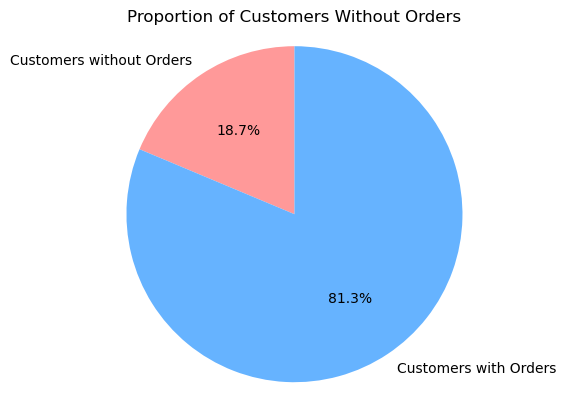

In [1112]:
# Total number of customers in the system
total_customers = len(df_Customers)

# Number of customers who have orders
num_customers_with_orders = total_customers - num_customers_without_orders

# Data for the pie chart
sizes = [num_customers_without_orders, num_customers_with_orders]
labels = ['Customers without Orders', 'Customers with Orders']

# Plotting the pie chart
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90, colors=['#ff9999','#66b3ff'])

# Adding a title to the chart
plt.title('Proportion of Customers Without Orders')

# Display the chart
plt.axis('equal')  # Ensuring the pie chart is circular
plt.show()


Out of the customers in the system, 17 customers have no orders,
which suggests that this group may either be new customers who haven't made a purchase yet,
or customers who have stopped making purchases.

<a href="#toc" role="button" aria-pressed="true">🔝 Back to Table of Contents 🔝</a>

# <a id="3.2"></a>
## <b>3.2 <span style='color:#F1A424'>Total Expenditure by Country: A Breakdown of Spending Across Regions</span></b>

In [1113]:
# دمج جدول الأوامر مع جدول العملاء للحصول على "Country" من جدول العملاء
merged_df = pd.merge(df_Orders, df_Customers[['CustomerID', 'Country']], on='CustomerID', how='left')

# دمج مع جدول تفاصيل الأوامر للحصول على الكمية والمنتجات
merged_df = pd.merge(merged_df, df_OrderDetails[['OrderID', 'ProductID', 'Quantity']], on='OrderID', how='left')

# دمج مع جدول المنتجات للحصول على الأسعار
merged_df = pd.merge(merged_df, df_Products[['ProductID', 'Price']], on='ProductID', how='left')

# حساب إجمالي الإنفاق لكل طلب بناءً على الكمية والسعر
merged_df['TotalSpent'] = merged_df['Quantity'] * merged_df['Price']

# حساب إجمالي الإنفاق لكل دولة
total_spent_by_region = merged_df.groupby('Country').agg(
    total_spent=('TotalSpent', 'sum')
).reset_index()

# ترتيب الدول حسب إجمالي المبيعات من الأكبر إلى الأصغر
total_spent_by_region_sorted = total_spent_by_region.sort_values(by='total_spent', ascending=False)
total_spent_by_region_sorted 

,Country,total_spent
19,USA,69611.75
1,Austria,51671.96
8,Germany,47241.82
3,Brazil,40215.25
4,Canada,31326.35
7,France,29549.15
5,Denmark,17870.85
18,UK,16695.79
9,Ireland,15391.02
20,Venezuela,13556.28


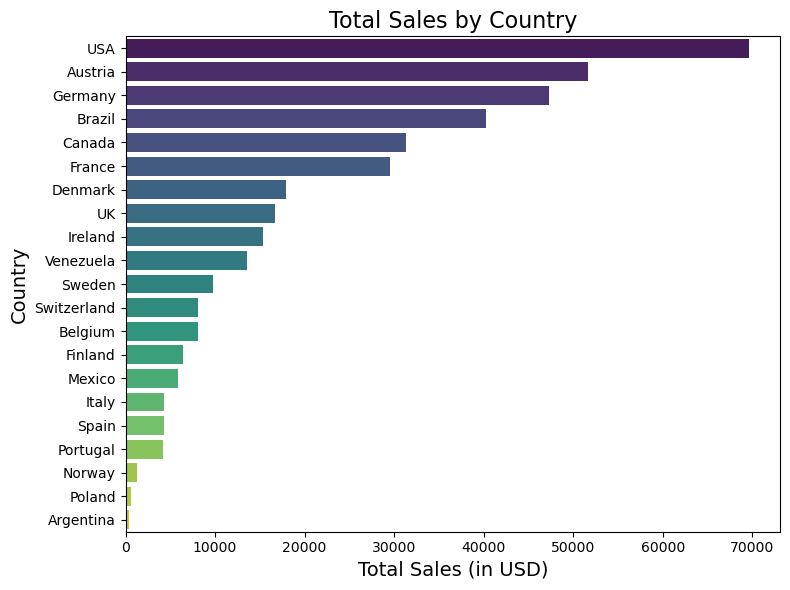

In [1114]:
# رسم المخطط الشريطي مع التحقق من ترتيب البيانات باستخدام order
plt.figure(figsize=(8, 6))
sns.barplot(x='total_spent', y='Country', data=total_spent_by_region_sorted, palette='viridis', 
            order=total_spent_by_region_sorted['Country'])

# إضافة العنوان والتسميات
plt.title('Total Sales by Country', fontsize=16)
plt.xlabel('Total Sales (in USD)', fontsize=14)
plt.ylabel('Country', fontsize=14)

# عرض المخطط
plt.tight_layout()
plt.show()


The United States (USA) is the leading market with the highest total sales, followed by Germany and Austria. 
Some countries like Argentina and Poland show very low sales. 
The large differences in sales suggest opportunities to expand marketing in smaller markets or improve strategies in countries with weak sales.

<a href="#toc" role="button" aria-pressed="true">🔝 Back to Table of Contents 🔝</a>

# <a id="3.3"></a>
## <b>3.3 <span style='color:#F1A424'>Total Sales by City and Country</span></b>

In [1115]:
# 1. حساب إجمالي الإنفاق حسب المدينة والبلد من جدول العملاء
total_spent_by_city_country = df_Customers.groupby(['Country', 'City']).agg(
    total_spent=('total_spent', 'sum')
).reset_index()

# 2. عرض الجدول النهائي مع إجمالي الإنفاق حسب المدينة والبلد
total_spent_by_city_country


,Country,City,total_spent
0,Argentina,Buenos Aires,399.00
1,Austria,Graz,35631.21
2,Austria,Salzburg,16040.75
3,Belgium,Bruxelles,0.00
4,Belgium,Charleroi,8051.30
...,...,...,...
64,USA,Walla Walla,0.00
65,Venezuela,Barquisimeto,7358.68
66,Venezuela,Caracas,1377.10
67,Venezuela,I. de Margarita,500.00


In [1116]:
import plotly.express as px

# تأكد أن المتغير city_sales_by_country يحتوي على بيانات مبيعات فعلية (أكبر من 0)
city_sales_by_country_non_zero = city_sales_by_country[city_sales_by_country['TotalSpent'] > 0]

# رسم المخطط الشجري (TreeMap)
fig = px.treemap(
    city_sales_by_country_non_zero, 
    path=['Country', 'City'],  # مسار الهيكلية (Country -> City)
    values='TotalSpent',  # القيم التي سيتم حسابها في المخطط
    color='TotalSpent',  # اللون بناءً على المبيعات
    hover_data=['City', 'TotalSpent'],  # عرض البيانات عند المرور على العنصر
    color_continuous_scale='Viridis',  # التدرج اللوني
    title='Total Sales by City and Country'  # العنوان
)

# عرض المخطط
fig.show()

Top Country by Sales: The United States of America is the country with the highest total sales.

Top City by Sales: The city of Graz in Austria recorded the highest sales among all cities.

<a href="#toc" role="button" aria-pressed="true">🔝 Back to Table of Contents 🔝</a>

# <a id="3.4"></a>
## <b>3.4 <span style='color:#F1A424'>Total Sales per Order per Month and Year</span></b>

In [1167]:
# إضافة عمود جديد يعبر عن الشهر والسنة لسهولة التجميع
df_Orders['YearMonth'] = df_Orders['OrderDate'].dt.to_period('M')

# دمج بيانات الطلبات مع تفاصيل الطلبات للحصول على الكميات والمبيعات
order_details = pd.merge(df_Orders, df_OrderDetails[['OrderID', 'ProductID', 'Quantity']], on='OrderID', how='left')
order_details = pd.merge(order_details, df_Products[['ProductID', 'Price']], on='ProductID', how='left')

# حساب المبيعات لكل طلب (Quantity * Price)
order_details['Total Sales'] = order_details['Quantity'] * order_details['Price']

# تجميع إجمالي المبيعات لكل شهر
monthly_sales = order_details.groupby('YearMonth')['Total Sales'].sum().reset_index()

# حساب التغير في إجمالي المبيعات بين كل شهر والشهر السابق
monthly_sales['Sales Change'] = monthly_sales['Total Sales'].diff()

# عرض التغيرات في إجمالي المبيعات
monthly_sales


,YearMonth,Total Sales,Sales Change
0,1996-07,37779.85,NaN
1,1996-08,33285.49,-4494.36
2,1996-09,34565.60,1280.11
3,1996-10,51528.69,16963.09
4,1996-11,62163.99,10635.30
5,1996-12,63721.23,1557.24
6,1997-01,83400.47,19679.24
7,1997-02,19978.91,-63421.56


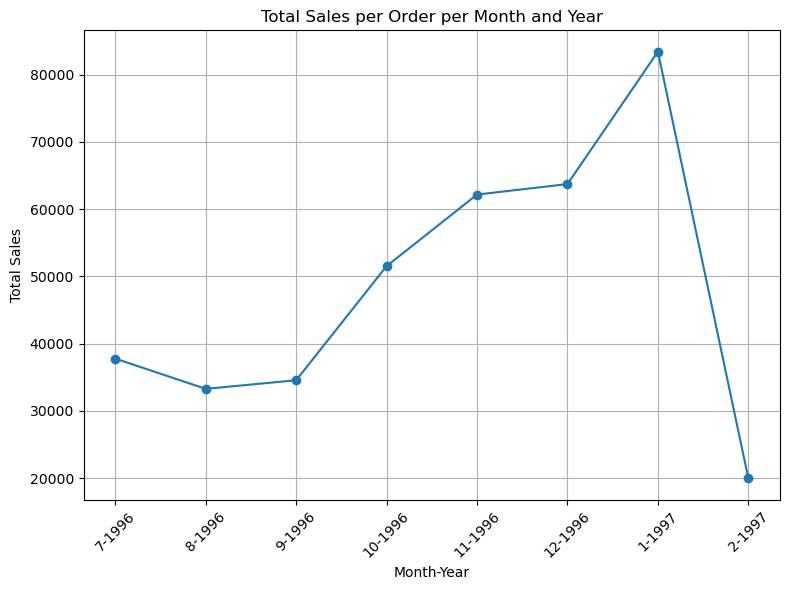

In [1168]:
# تجميع البيانات حسب السنة والشهر لحساب إجمالي المبيعات لكل شهر
monthly_sales = df_Orders_with_total.groupby(['Year', 'Month'])['Total Sales'].sum().reset_index()

# تحويل اسم الشهر إلى رقم إذا كانت البيانات بالشهر النصي (مثل 'January', 'February', ...)
# لكن إذا كانت البيانات عبارة عن أرقام، فلا حاجة لهذه الخطوة
# في حال كانت بيانات الشهر نصية، يمكن تحويلها:
# monthly_sales['Month'] = pd.to_datetime(monthly_sales['Month'], format='%B').dt.month

# ترتيب البيانات حسب السنة والشهر
monthly_sales = monthly_sales.sort_values(by=['Year', 'Month'])

# إنشاء عمود جديد لتمثيل "Month-Year" للمحور السيني
monthly_sales['Month-Year'] = monthly_sales['Month'].astype(str) + '-' + monthly_sales['Year'].astype(str)

# رسم المخطط الخطي
plt.figure(figsize=(8,6))
plt.plot(monthly_sales['Month-Year'], monthly_sales['Total Sales'], marker='o')

# تنسيق المحور السيني
plt.xticks(rotation=45)

# إضافة العنوان والتسميات للمحاور
plt.title('Total Sales per Order per Month and Year')
plt.xlabel('Month-Year')
plt.ylabel('Total Sales')

# إضافة الشبكة لتحسين العرض
plt.grid(True)

# تحسين توزيع العناصر في المخطط
plt.tight_layout()

# عرض المخطط
plt.show()


In [1169]:
# دمج order_details مع جدول المنتجات للحصول على CategoryID
order_details_with_category = pd.merge(order_details, df_Products[['ProductID', 'CategoryID']], on='ProductID', how='left')

# تجميع مبيعات كل صنف شهريًا باستخدام CategoryID
monthly_sales_by_category = order_details_with_category.groupby(['YearMonth', 'CategoryID'])['Total Sales'].sum().reset_index()

# حساب التغير في مبيعات كل صنف بين الشهور
monthly_sales_by_category['Sales Change'] = monthly_sales_by_category.groupby('CategoryID')['Total Sales'].diff()

# دمج مع جدول الفئات للحصول على اسم الفئة
monthly_sales_by_category_with_name = pd.merge(monthly_sales_by_category, df_Categories[['CategoryID', 'CategoryName']], on='CategoryID', how='left')

# التأكد من وجود بيانات مبيعات (إزالة NaN في Sales Change)
monthly_sales_by_category_with_name = monthly_sales_by_category_with_name.dropna(subset=['Sales Change'])

# إعادة هيكلة البيانات بحيث تكون الأعمدة هي الأشهر والفئات هي الصفوف
pivot_table = monthly_sales_by_category_with_name.pivot_table(
    index='YearMonth',  # شهر السنة
    columns='CategoryName',  # الأصناف (الفئات)
    values='Sales Change',  # التغير في المبيعات
    aggfunc='sum',  # تجميع القيم بشكل صحيح
).reset_index()

# عرض الجدول النهائي
pivot_table

CategoryName,YearMonth,Beverages,Condiments,Confections,Dairy Products,Grains/Cereals,Meat/Poultry,Produce,Seafood
0,1996-08,1998.0,192.45,-1296.35,-3082.0,-1271.25,1358.25,-4186.25,1792.79
1,1996-09,119.0,-592.65,1535.10,-786.2,685.75,913.85,441.20,-1035.94
2,1996-10,4577.0,3394.00,-3315.63,4788.0,2102.50,-782.25,2164.95,4034.52
3,1996-11,13648.5,2929.65,-711.24,-478.0,123.25,2475.36,-603.35,-6748.87
4,1996-12,-9930.0,-6666.55,4150.22,5537.6,-308.25,4418.25,1584.05,2771.92
5,1997-01,15570.5,5141.40,3797.06,-2871.1,2771.25,-2062.07,-981.90,-1685.90
6,1997-02,-28445.5,-3545.00,-8526.66,-10540.0,-1387.25,-5666.33,-2775.75,-2535.07


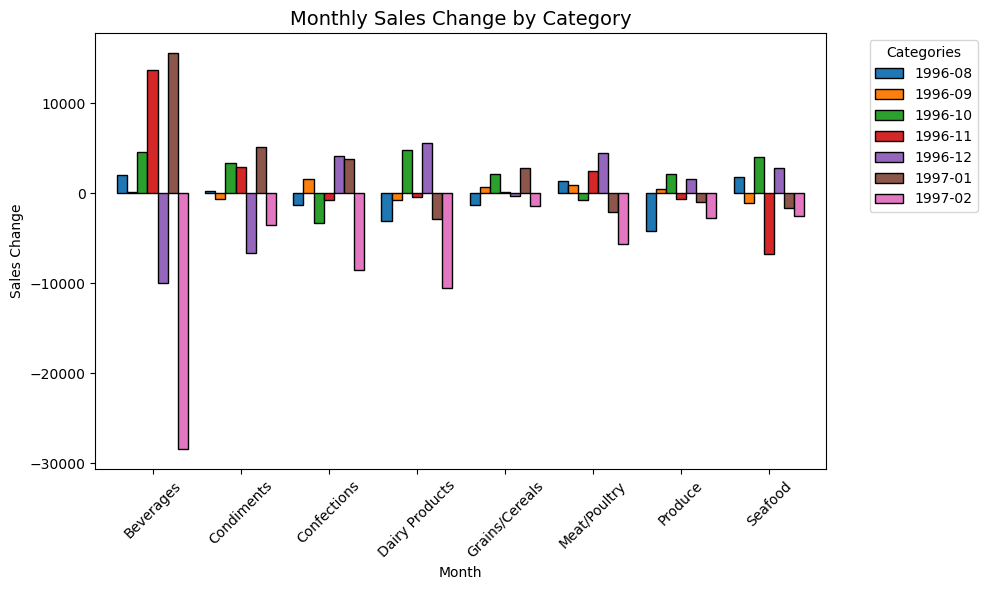

In [1173]:
#  رسم المخطط
fig, ax = plt.subplots(figsize=(10, 6))

# رسم المخطط الشريطي للتغير في المبيعات لكل صنف عبر الأشهر
pivot_table.set_index('YearMonth').T.plot(kind='bar', ax=ax, width=0.8, edgecolor='black')

# إضافة عنوان للمخطط
ax.set_title('Monthly Sales Change by Category', fontsize=14)

# إضافة تسميات للمحاور
ax.set_xlabel('Month')
ax.set_ylabel('Sales Change')

# تدوير تسميات الأشهر على المحور X لسهولة القراءة
plt.xticks(rotation=45)

# إضافة وسيلة إيضاح (Legend)
plt.legend(title='Categories', bbox_to_anchor=(1.05, 1), loc='upper left')

# عرض المخطط
plt.tight_layout()
plt.show()

#### Detailed sales changes of categories during each month:

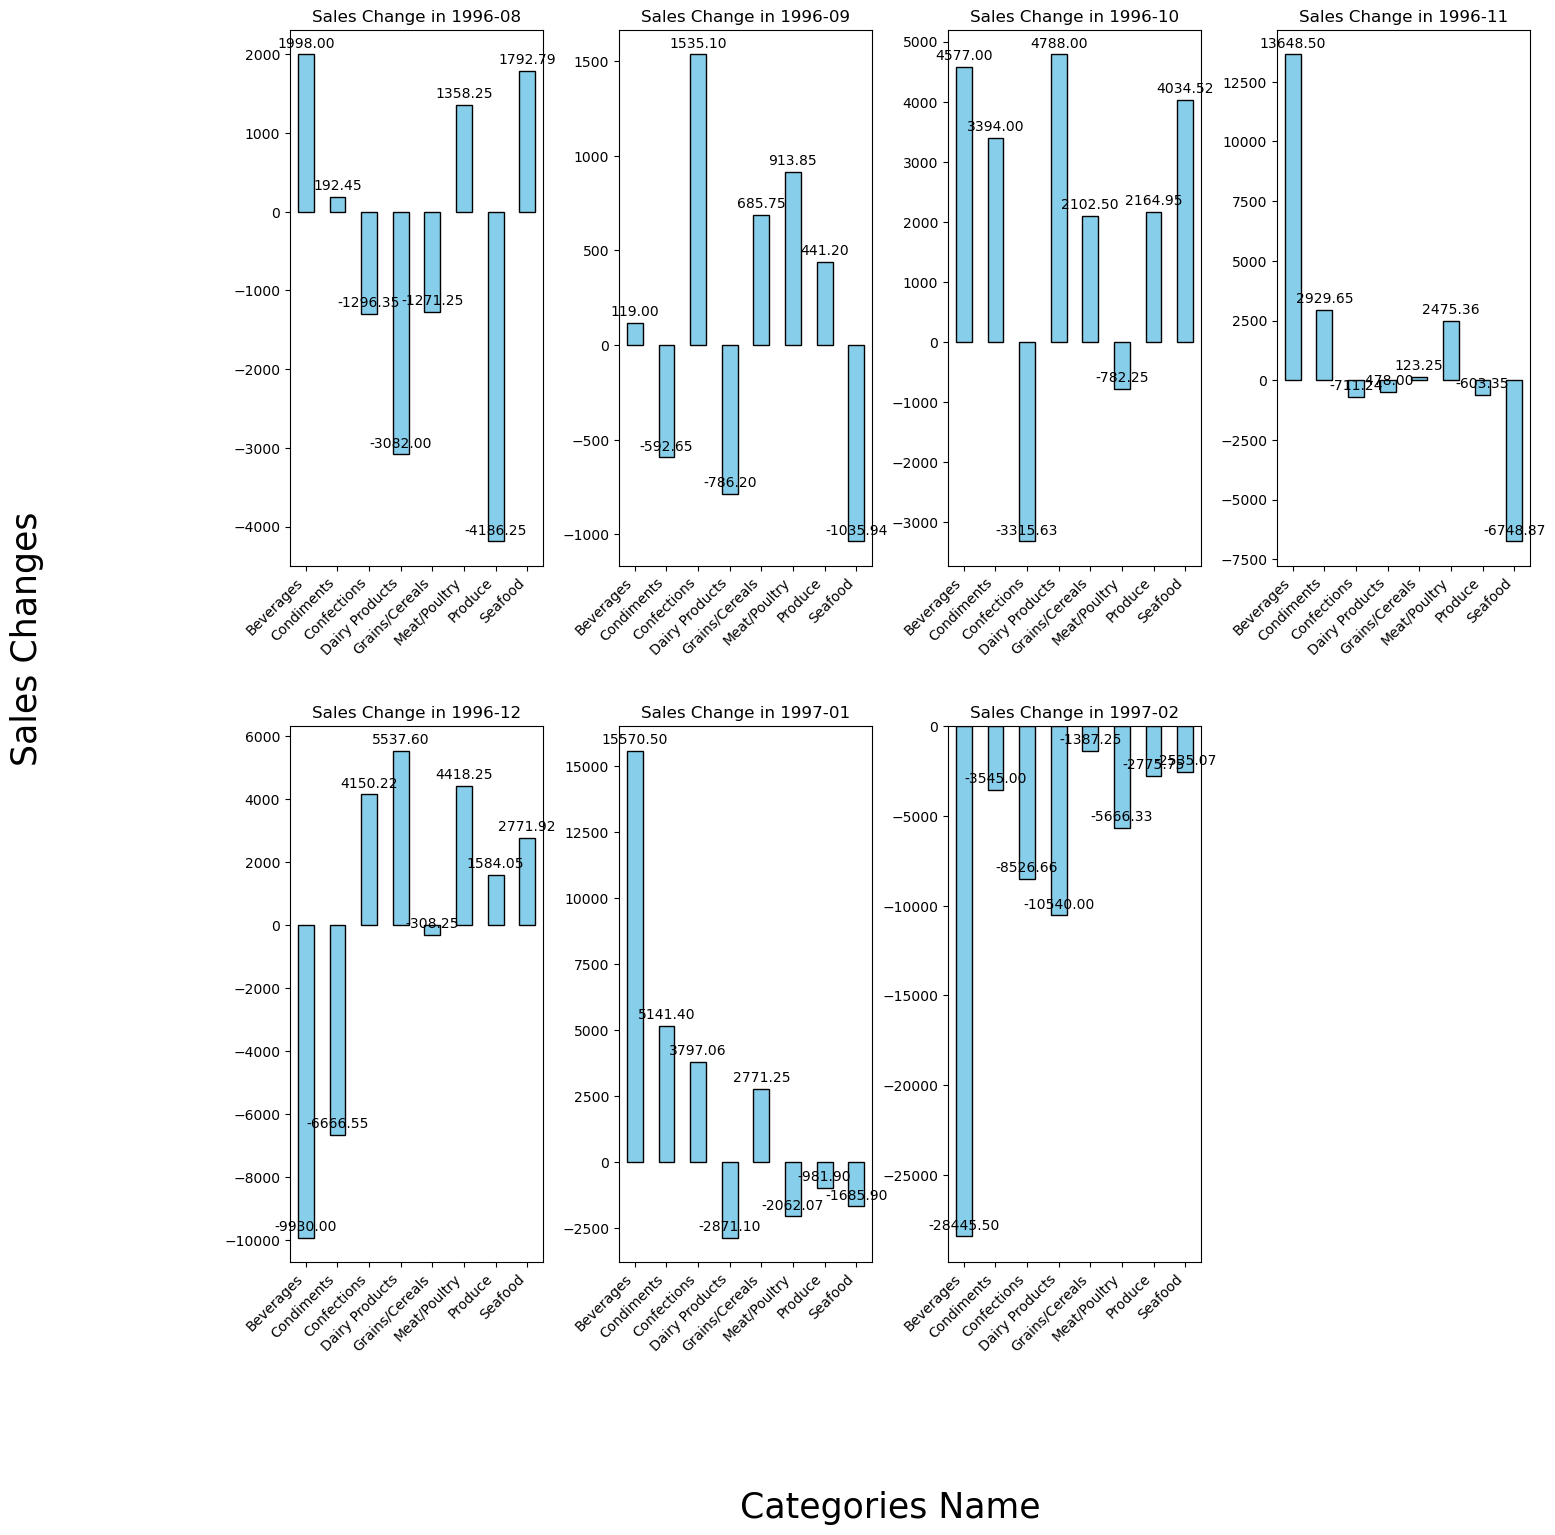

In [1174]:
# إعداد الشكل مع 2 صفوف و 4 أعمدة (لأن لدينا 7 أشهر على سبيل المثال)
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(16, 1))

# تسطيح المحاور لتسهيل الوصول إليها
axes = axes.flatten()

# رسم المخططات لكل شهر
for i, month in enumerate(pivot_table['YearMonth']):
    ax = axes[i]
    
    # رسم المخطط الشريطي لكل شهر
    pivot_table.set_index('YearMonth').loc[month].plot(kind='bar', ax=ax, color='skyblue', edgecolor='black')
    
    # إضافة الأرقام داخل الأشرطة
    for p in ax.patches:
        height = p.get_height()
        ax.annotate(f'{height:.2f}', 
                    (p.get_x() + p.get_width() / 2., height), 
                    ha='center', va='center', 
                    fontsize=10, color='black', 
                    xytext=(0, 8), textcoords='offset points')

    # تخصيص العنوان للمخطط الفرعي
    ax.set_title(f'Sales Change in {month}', fontsize=12)
    
    # إضافة تسميات المحور X للمخططات الفرعية (عرض أسماء الفئات)
    ax.set_xticklabels(pivot_table.columns[1:], rotation=45, ha='right')
    
    # إخفاء تسميات المحور X (من كلمة "Category Name")
    ax.set_xlabel('')

# تخصيص المحور العام للمخططات
fig.text(0.5, -0.05, 'Categories Name', ha='center', fontsize=25)  # عنوان المحور X العام
fig.text(-0.05, 0.5, 'Sales Changes', va='center', rotation='vertical', fontsize=25)  # عنوان المحور Y العام

# حذف المحور الفارغ (المخطط الأخير في الشبكة)
axes[-1].axis('off')

# تخصيص المسافات بين المخططات
plt.subplots_adjust(hspace=0.3, wspace=0.3)  # تخصيص المسافة بين المخططات

# عرض المخطط
plt.show()


The data shows significant fluctuations in sales across categories over the months.
Beverages saw a sharp increase in October 1996, while Seafood and Produce experienced continuous declines
in most months, indicating possible stock shortages or changes in demand. Additionally, 
Confections and Dairy Products showed notable increases during certain periods.

<a href="#toc" role="button" aria-pressed="true">🔝 Back to Table of Contents 🔝</a>

# <a id="3.5"></a>
## <b>3.5 <span style='color:#F1A424'>Difference Between Available and Ordered Quantities by Category</span></b>

In [1175]:
# 1. تجميع الكميات المطلوبة حسب ProductID في جدول الأوامر
category_order_group = df_OrderDetails.groupby('ProductID')['Quantity'].sum().reset_index()

# 2. دمج النتائج مع بيانات المنتجات لاستخراج CategoryID و Available لكل منتج
merged_category_df = pd.merge(category_order_group, df_Products[['ProductID', 'CategoryID', 'Available']], on='ProductID', how='left')

# 3. تجميع الكميات المطلوبة والمتوفرة حسب CategoryID
category_summary = merged_category_df.groupby('CategoryID').agg({
    'Quantity': 'sum',   # إجمالي الكميات المطلوبة لكل فئة
    'Available': 'sum'   # إجمالي الكميات المتوفرة لكل فئة
}).reset_index()

# 4. حساب الفرق بين المتوفر والمطلوب لكل فئة
category_summary['Available - Ordered'] = category_summary['Available'] - category_summary['Quantity']

# 5. إضافة عمود لعرض حالة الفائض أو النقص (إذا كانت الكميات المتوفرة أكبر من أو تساوي المطلوبة)
category_summary['Stock Status'] = category_summary['Available - Ordered'].apply(
    lambda x: 'Sufficient Stock' if x >= 0 else 'Stock Shortage'
)

# 6. عرض النتيجة النهائية مع ترتيب البيانات حسب CategoryID
category_summary = category_summary.sort_values(by='CategoryID')

# 7. عرض النتائج
category_summary


,CategoryID,Quantity,Available,Available - Ordered,Stock Status
0,1,2289,945,-1344,Stock Shortage
1,2,1383,271,-1112,Stock Shortage
2,3,2110,430,-1680,Stock Shortage
3,4,2601,611,-1990,Stock Shortage
4,5,912,152,-760,Stock Shortage
5,6,1288,176,-1112,Stock Shortage
6,7,715,132,-583,Stock Shortage
7,8,1445,165,-1280,Stock Shortage


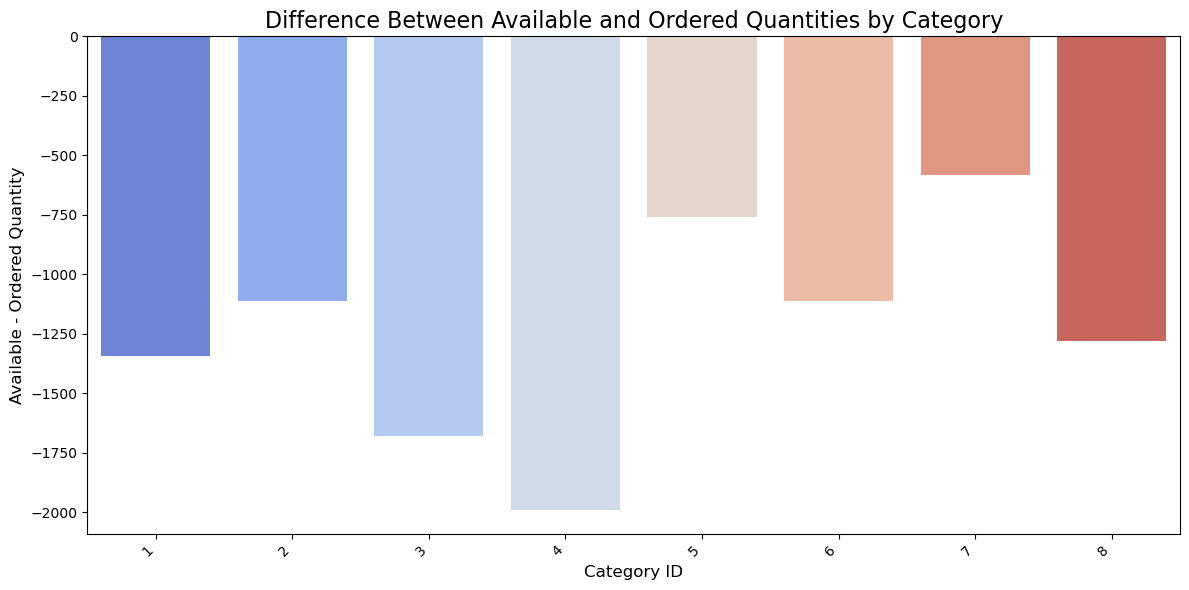

In [1176]:
# ترتيب البيانات حسب الفارق
category_summary = category_summary.sort_values(by='Available - Ordered', ascending=False)

# إعداد المخطط
plt.figure(figsize=(12, 6))

# رسم المخطط الشريطي باستخدام seaborn
sns.barplot(x='CategoryID', y='Available - Ordered', data=category_summary, palette='coolwarm')

# إضافة تسميات للمخطط
plt.title('Difference Between Available and Ordered Quantities by Category', fontsize=16)
plt.xlabel('Category ID', fontsize=12)
plt.ylabel('Available - Ordered Quantity', fontsize=12)
plt.xticks(rotation=45, ha='right')  # تدوير التسميات على المحور X لتكون أكثر وضوحًا

# عرض المخطط
plt.tight_layout()
plt.show()


The data shows a stock shortage for several categories, indicating high and unmet demand for certain products.
Increasing available quantities is necessary to balance supply with demand and improve inventory strategies.

<a href="#toc" role="button" aria-pressed="true">🔝 Back to Table of Contents 🔝</a>

# <a id="3.6"></a>
## <b>3.6 <span style='color:#F1A424'>Stock Difference for Each Product</span></b>

In [1177]:
# دمج البيانات بين جدول المنتجات (df_Products) و جدول تفاصيل الأوامر (df_OrderDetails)
merged_df = pd.merge(df_Products, df_OrderDetails, on='ProductID', how='left')

# حساب مجموع الكميات المطلوبة لكل صنف (Total Ordered Quantity)
total_quantity_ordered = merged_df.groupby('ProductID')['Quantity'].sum().reset_index()
total_quantity_ordered = total_quantity_ordered.rename(columns={'Quantity': 'Quantity_TotalOrdered'})

# دمج مجموع الكميات المطلوبة مع بيانات المنتجات مرة أخرى
merged_df = pd.merge(merged_df, total_quantity_ordered, on='ProductID', how='left')

# حساب الفارق بين المتوفر في جدول المنتجات و مجموع الكميات المطلوبة
merged_df['Stock Difference'] = merged_df['Available'] - merged_df['Quantity_TotalOrdered']

# إضافة عمود CategoryID من جدول df_Products
result = merged_df[['ProductID', 'ProductName', 'CategoryID', 'Available', 'Quantity_TotalOrdered', 'Stock Difference']].drop_duplicates()

# عرض النتيجة النهائية
result


,ProductID,ProductName,CategoryID,Available,Quantity_TotalOrdered,Stock Difference
0,1,Chais,1,10,159,-149
8,2,Chang,1,24,341,-317
19,3,Aniseed Syrup,2,12,80,-68
21,4,Chef Anton's Cajun Seasoning,2,48,107,-59
26,5,Chef Anton's Gumbo Mix,2,36,129,-93
...,...,...,...,...,...,...
483,73,Röd Kaviar,8,24,45,-21
485,74,Longlife Tofu,7,5,186,-181
492,75,Rhönbräu Klosterbier,1,24,144,-120
500,76,Lakkalikööri,1,1,198,-197


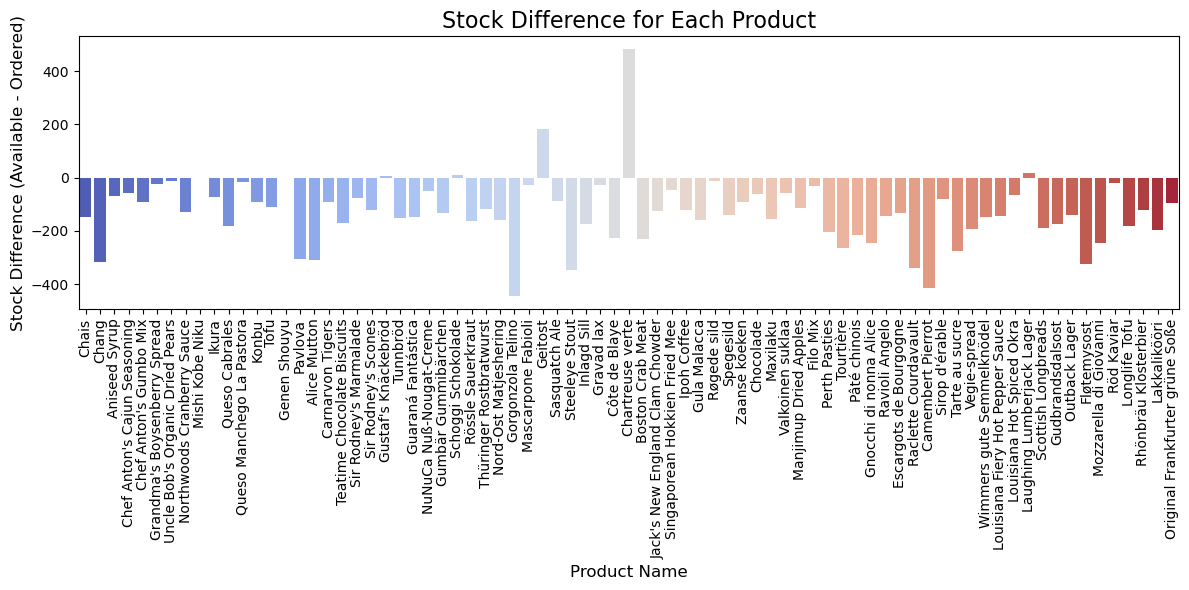

In [1178]:
# إعداد المخطط
plt.figure(figsize=(12, 6))

# رسم المخطط الشريطي باستخدام seaborn
sns.barplot(x='ProductName', y='Stock Difference', data=result, palette='coolwarm')

# إضافة تسميات للمخطط
plt.title('Stock Difference for Each Product', fontsize=16)
plt.xlabel('Product Name', fontsize=12)
plt.ylabel('Stock Difference (Available - Ordered)', fontsize=12)

# تدوير التسميات على المحور X لتكون واضحة
plt.xticks(rotation=90)

# تحسين المسافات بين العناصر
plt.tight_layout()

# عرض المخطط
plt.show()


In [1179]:
# حساب عدد القيم السالبة في عمود Stock Difference
negative_stock_count = (result['Stock Difference'] < 0).sum()

# عرض النتيجة
print(f"The number of negative values in the 'Stock Difference' column is': {negative_stock_count}")


The number of negative values in the 'Stock Difference' column is': 72


In [1180]:
# تصفية الأسطر بناءً على القيم الموجبة في عمود 'Stock Difference'
positive_stock_df = result[result['Stock Difference'] > 0]

# عرض النتيجة
positive_stock_df

,ProductID,ProductName,CategoryID,Available,Quantity_TotalOrdered,Stock Difference
117,22,Gustaf's Knäckebröd,5,24,18,6
146,27,Schoggi Schokolade,3,100,90,10
193,33,Geitost,4,500,316,184
236,39,Chartreuse verte,1,750,266,484
426,67,Laughing Lumberjack Lager,1,24,5,19


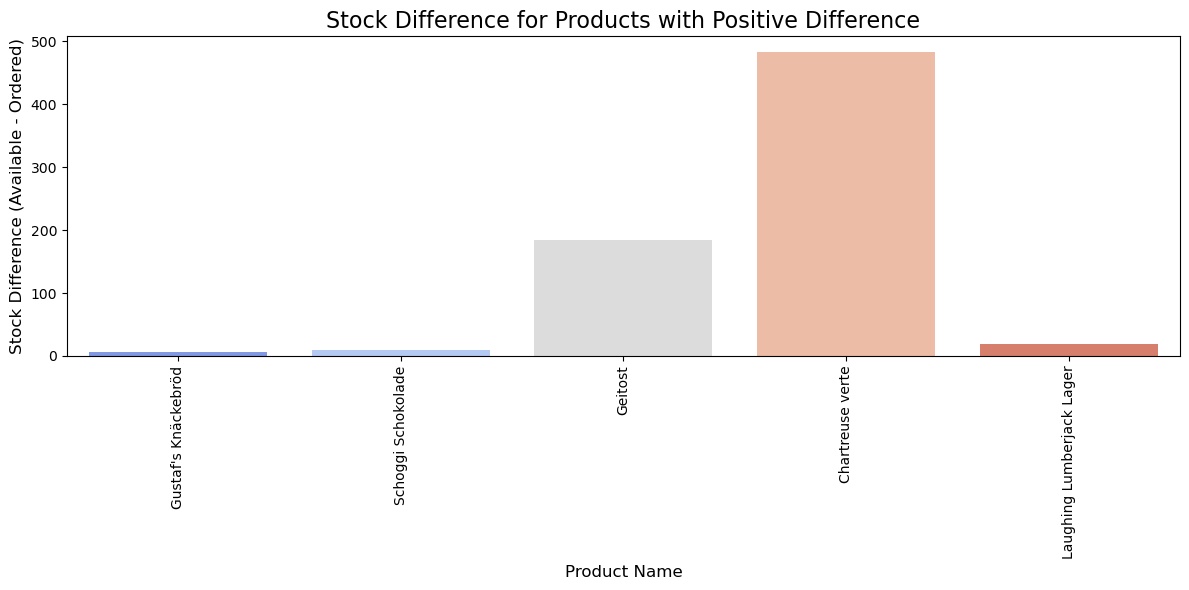

In [1181]:
# إعداد المخطط
plt.figure(figsize=(12, 6))

# رسم المخطط الشريطي باستخدام seaborn
sns.barplot(x='ProductName', y='Stock Difference', data=positive_stock_df, palette='coolwarm')

# إضافة تسميات للمخطط
plt.title('Stock Difference for Products with Positive Difference', fontsize=16)
plt.xlabel('Product Name', fontsize=12)
plt.ylabel('Stock Difference (Available - Ordered)', fontsize=12)

# تدوير التسميات على المحور X لتكون واضحة
plt.xticks(rotation=90)

# عرض المخطط
plt.tight_layout()
plt.show()


Although some products in categories 1, 3, 4, and 5 are available, the overall stock calculation shows a significant shortage because the required quantities were compared to available stock at the category level, not at the individual product level.

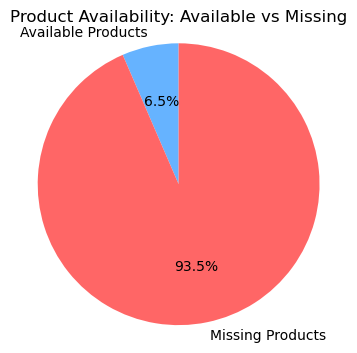

In [1182]:
# عدد المنتجات المتوفرة والمفقودة
products_available = 5
products_missing = 72

# إعداد البيانات للمخطط
labels = ['Available Products', 'Missing Products']
sizes = [products_available, products_missing]
colors = ['#66b3ff', '#ff6666']  # ألوان مخصصة للمخطط

# رسم المخطط الدائري
plt.figure(figsize=(4, 4))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90, colors=colors)

# إضافة عنوان للمخطط
plt.title('Product Availability: Available vs Missing')

# عرض المخطط
plt.axis('equal')  # لضمان أن يكون المخطط دائريًا
plt.show()


The ratio between available and missing products shows that 93.5% of the products are missing, while only 6.5% are available in stock. This large gap indicates a significant stock shortage that could impact order fulfillment.

<a href="#toc" role="button" aria-pressed="true">🔝 Back to Table of Contents 🔝</a>

# <a id="3.7"></a>
## <b>3.7 <span style='color:#F1A424'>Total Sales by Season</span></b>

C:\Users\LEGION\AppData\Local\Temp\ipykernel_17960\2970933184.py:14: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

C:\Users\LEGION\anaconda3\Lib\site-packages\seaborn\categorical.py:641: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



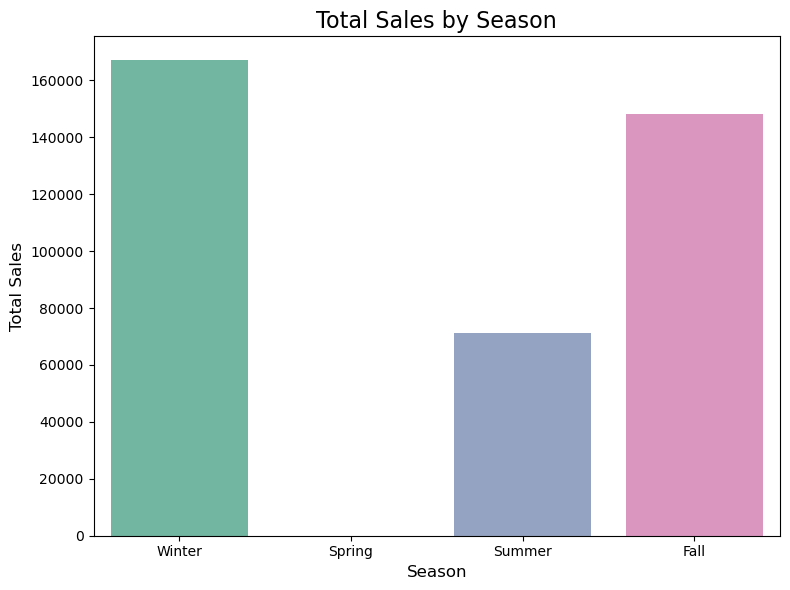

In [1183]:
# دمج مع تفاصيل الطلبات (df_OrderDetails) للحصول على الكميات والأسعار
# افترض أن df_Orders و df_OrderDetails و df_Products تحتوي على البيانات المطلوبة

# دمج بيانات الطلبات مع تفاصيل الطلبات للحصول على الكميات
order_details = pd.merge(df_Orders, df_OrderDetails[['OrderID', 'ProductID', 'Quantity']], on='OrderID', how='left')

# دمج مع جدول المنتجات للحصول على الأسعار
order_details = pd.merge(order_details, df_Products[['ProductID', 'Price']], on='ProductID', how='left')

# حساب مبيعات كل طلب (Quantity * Price)
order_details['Total Sales'] = order_details['Quantity'] * order_details['Price']

# تجميع المبيعات حسب الموسم
season_sales = order_details.groupby('Season')['Total Sales'].sum().reset_index()

# ترتيب المبيعات حسب الموسم من الأعلى إلى الأقل
season_sales_sorted = season_sales.sort_values(by='Total Sales', ascending=False)

# رسم بياني للمبيعات حسب الموسم
plt.figure(figsize=(8, 6))
sns.barplot(x='Season', y='Total Sales', data=season_sales_sorted, palette='Set2')

# تخصيص العنوان والمحاور
plt.title('Total Sales by Season', fontsize=16)
plt.xlabel('Season', fontsize=12)
plt.ylabel('Total Sales', fontsize=12)

# عرض المخطط
plt.tight_layout()
plt.show()


The Winter and Fall seasons generate the highest sales, with Winter slightly surpassing Fall.
Summer sees the lowest sales, which could reflect seasonal trends or demand for certain products.

<a href="#toc" role="button" aria-pressed="true">🔝 Back to Table of Contents 🔝</a>

# <a id="3.8"></a>
## <b>3.8 <span style='color:#F1A424'>Total Sales by Product and Category</span></b>

In [1184]:
# دمج بيانات الأوامر مع تفاصيل الطلبات
order_details = pd.merge(df_Orders, df_OrderDetails[['OrderID', 'ProductID', 'Quantity']], on='OrderID', how='left')

# دمج مع بيانات المنتجات للحصول على السعر والفئة واسم المنتج
order_details = pd.merge(order_details, df_Products[['ProductID', 'ProductName', 'CategoryID', 'Price']], on='ProductID', how='left')

# حساب إجمالي المبيعات لكل منتج (Quantity * Price)
order_details['Total Sales'] = order_details['Quantity'] * order_details['Price']

# تجميع المبيعات حسب ProductID للحصول على إجمالي المبيعات لكل منتج
product_sales = order_details.groupby(['ProductID', 'ProductName'])['Total Sales'].sum().reset_index()

# تجميع المبيعات حسب CategoryID للحصول على إجمالي المبيعات لكل فئة
category_sales = order_details.groupby('CategoryID')['Total Sales'].sum().reset_index()

# دمج مع بيانات الفئات للحصول على أسماء الفئات
category_sales = pd.merge(category_sales, df_Categories[['CategoryID', 'CategoryName']], on='CategoryID')

# دمج المبيعات حسب المنتج مع بيانات الفئات للحصول على إجمالي المبيعات لكل فئة من المنتجات
product_sales = pd.merge(product_sales, df_Products[['ProductID', 'CategoryID']], on='ProductID', how='left')
product_sales = pd.merge(product_sales, df_Categories[['CategoryID', 'CategoryName']], on='CategoryID', how='left')

# عرض النتائج
product_sales[['CategoryName', 'ProductName', 'Total Sales']]

,CategoryName,ProductName,Total Sales
0,Beverages,Chais,2862.00
1,Beverages,Chang,6479.00
2,Condiments,Aniseed Syrup,800.00
3,Condiments,Chef Anton's Cajun Seasoning,2354.00
4,Condiments,Chef Anton's Gumbo Mix,2754.15
...,...,...,...
72,Seafood,Röd Kaviar,675.00
73,Produce,Longlife Tofu,1860.00
74,Beverages,Rhönbräu Klosterbier,1116.00
75,Beverages,Lakkalikööri,3564.00


In [1265]:
import plotly.express as px

# عرض البيانات اللازمة للمخطط الشجري
tree_data = product_sales[['CategoryName', 'ProductName', 'Total Sales']]

# استخدام Plotly لإنشاء المخطط الشجري
fig = px.sunburst(tree_data, path=['CategoryName', 'ProductName'], values='Total Sales', 
                  title="Sales by Product and Category",
                  color='Total Sales', 
                  color_continuous_scale="RdBu", 
                  labels={'Total Sales': 'Sales Amount'})

# عرض المخطط
fig.show()


#### Another chart for clarification

In [1186]:
# بناء هيكل الشجرة باستخدام البيانات المجمعة
# أولاً، نحن بحاجة لتجميع البيانات بشكل هرمي (فئة -> منتج)
category_sales = product_sales[['CategoryName', 'ProductName', 'Total Sales']]

# بناء قائمة من العقد (Node) في الشجرة
nodes = []
for _, row in category_sales.iterrows():
    nodes.append({
        'label': row['ProductName'],
        'parent': row['CategoryName'],
        'value': row['Total Sales']
    })

# جمع العقد الفئات في الشجرة
categories = category_sales['CategoryName'].unique()

# بناء البيانات المستخدمة في المخطط الشجري
labels = list(categories) + [node['label'] for node in nodes]
parents = [''] * len(categories) + [node['parent'] for node in nodes]
values = [0] * len(categories) + [node['value'] for node in nodes]

# إنشاء مخطط شجري باستخدام plotly
fig = go.Figure(go.Treemap(
    labels=labels,
    parents=parents,
    values=values,
    textinfo="label+value+percent entry",
    hoverinfo="label+value+percent entry",
    marker=dict(colors=values, colorscale="Viridis")
))

# تخصيص المخطط
fig.update_layout(
    title="Sales by Product and Category",
    title_x=0.5,
    margin=dict(t=50, l=25, r=25, b=25)
)

# عرض المخطط
fig.show()


The Dairy Products category is the highest in sales with a total of 69,921.00,surpassing Beverages which ranks third. 
Although Beverages contains some of the top-selling products,Dairy Products dominates in total sales.
The data provides total sales for each product within different categories,
helping to understand the performance of products by category. 
It's important to analyze sales regularly to identify best-selling products and tailor strategies based on actual demand.

<a href="#toc" role="button" aria-pressed="true">🔝 Back to Table of Contents 🔝</a>

# <a id="3.9"></a>
## <b>3.9 <span style='color:#F1A424'>Comparison of Total Sales and Total Quantity per Category, Product and Supplier</span></b>

#### Comparison of Total Sales and Total Quantity by Category

In [1187]:
# دمج جدول df_Orders مع جدول df_OrderDetails للحصول على ProductID و Quantity
order_details = pd.merge(df_Orders, df_OrderDetails[['OrderID', 'ProductID', 'Quantity']], on='OrderID', how='left')

# دمج جدول df_Products للحصول على CategoryID وسعر المنتج
order_details_with_category = pd.merge(order_details, df_Products[['ProductID', 'CategoryID', 'Price']], on='ProductID', how='left')

# دمج جدول df_Categories للحصول على CategoryName (اسم الصنف)
order_details_with_category = pd.merge(order_details_with_category, df_Categories[['CategoryID', 'CategoryName']], on='CategoryID', how='left')

# حساب إجمالي المبيعات لكل منتج (Quantity * Price)
order_details_with_category['Total Sales'] = order_details_with_category['Quantity'] * order_details_with_category['Price']

# تجميع البيانات حسب CategoryName وحساب إجمالي الكميات والمبيعات لكل صنف
category_summary = order_details_with_category.groupby('CategoryName').agg(
    Total_Quantity=('Quantity', 'sum'),
    Total_Sales=('Total Sales', 'sum')
).reset_index()

# عرض النتيجة
category_summary


,CategoryName,Total_Quantity,Total_Sales
0,Beverages,2289,99464.50
1,Condiments,1383,35071.60
2,Confections,2110,54909.16
3,Dairy Products,2601,69921.00
4,Grains/Cereals,912,22327.75
5,Meat/Poultry,1288,51676.52
6,Produce,715,23401.40
7,Seafood,1445,29652.30


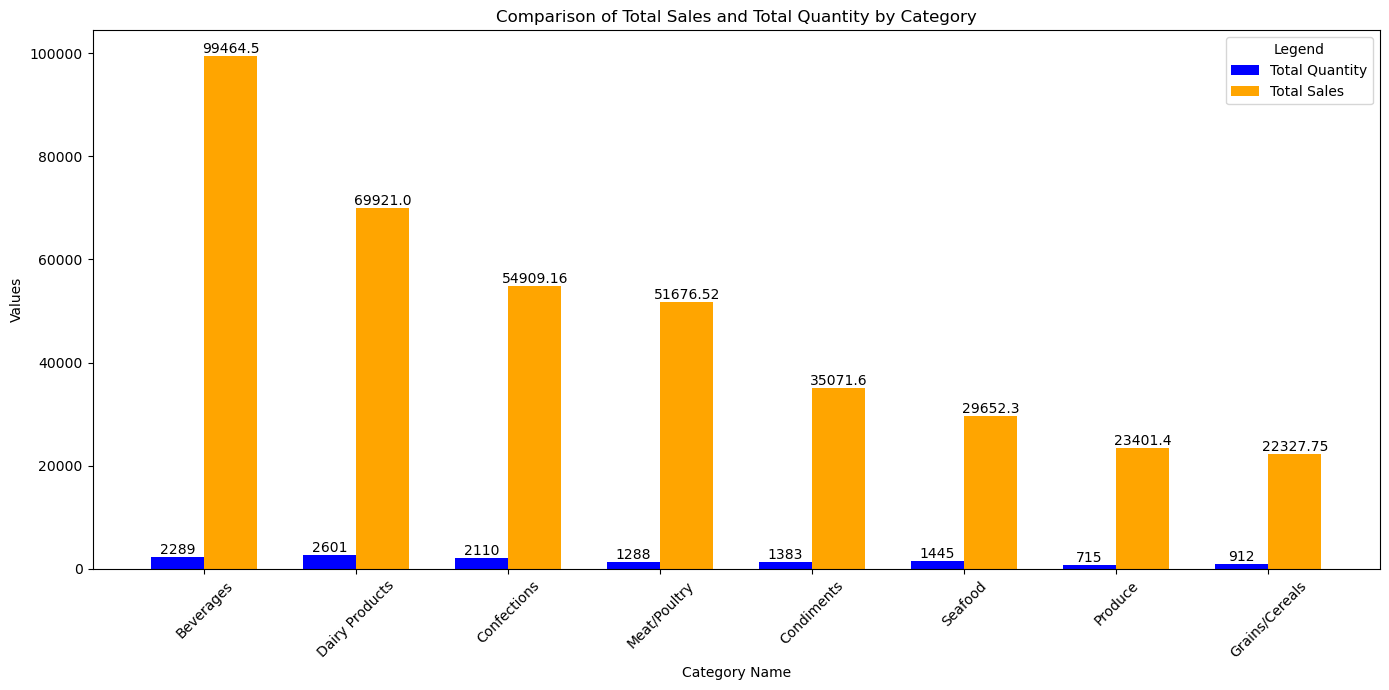

In [1188]:
# ترتيب الاعمدة 
category_summary = category_summary.sort_values(by='Total_Sales', ascending=False)

# إعداد حجم الرسم
plt.figure(figsize=(14, 7))

# عرض الأعمدة المزدوجة
bar_width = 0.35  # عرض الشريطين
index = np.arange(len(category_summary))  # تحديد مواقع الأعمدة

# رسم الأعمدة لأول مجموعة (Total Quantity)
bars1 = plt.bar(index, category_summary['Total_Quantity'], bar_width, label='Total Quantity', color='blue')

# رسم الأعمدة للمجموعة الثانية (Total Sales)
bars2 = plt.bar(index + bar_width, category_summary['Total_Sales'], bar_width, label='Total Sales', color='orange')

# إضافة الأرقام على الأعمدة
for bar in bars1:
    yval = bar.get_height()  # الحصول على ارتفاع الشريط (القيمة)
    plt.text(bar.get_x() + bar.get_width() / 2, yval + 10, round(yval, 2), ha='center', va='bottom', color='black')  # إضافة الرقم على الشريط

for bar in bars2:
    yval = bar.get_height()  # الحصول على ارتفاع الشريط (القيمة)
    plt.text(bar.get_x() + bar.get_width() / 2, yval + 10, round(yval, 2), ha='center', va='bottom', color='black')  # إضافة الرقم على الشريط

# تخصيص الرسم البياني
plt.title('Comparison of Total Sales and Total Quantity by Category')
plt.xlabel('Category Name')
plt.ylabel('Values')
plt.xticks(index + bar_width / 2, category_summary['CategoryName'], rotation=45)  # تخصيص تسميات الفئات على المحور X
plt.legend(title='Legend')  # إضافة وسيلة إيضاح

# عرض الرسم البياني
plt.tight_layout()
plt.show()


Although the quantities sold are almost equal between the categories, 
the difference in total sales is due to the price variations.
Categories like Dairy Products and Confections achieve higher sales
due to their higher prices compared to Grains/Cereals and Produce.

#### Comparison of Total Sales and Total Quantity by Product

In [1200]:
# دمج البيانات (الطلبات + التفاصيل + الأسعار + الفئات)
order_details = pd.merge(df_Orders, df_OrderDetails[['OrderID', 'ProductID', 'Quantity']], on='OrderID', how='left')
order_details = pd.merge(order_details, df_Products[['ProductID', 'CategoryID', 'Price', 'ProductName']], on='ProductID', how='left')

# دمج مع بيانات الفئات للحصول على CategoryName (اسم الصنف)
order_details_with_category = pd.merge(order_details, df_Categories[['CategoryID', 'CategoryName']], on='CategoryID', how='left')

# حساب إجمالي المبيعات لكل منتج (Quantity * Price)
order_details_with_category['Total Sales'] = order_details_with_category['Quantity'] * order_details_with_category['Price']

# تجميع البيانات حسب اسم المنتج وحساب إجمالي الكميات والمبيعات لكل منتج
product_summary = order_details_with_category.groupby('ProductName').agg(
    Total_Quantity=('Quantity', 'sum'),
    Total_Sales=('Total Sales', 'sum')
).reset_index()

# ترتيب البيانات حسب إجمالي المبيعات (Total Sales) بشكل تنازلي
product_summary_sorted = product_summary.sort_values(by='Total_Sales', ascending=False)

# عرض الجدول
product_summary_sorted


,ProductName,Total_Quantity,Total_Sales
11,Côte de Blaye,239,62976.50
68,Thüringer Rostbratwurst,168,20796.72
51,Raclette Courdavault,346,19030.00
66,Tarte au sucre,325,16022.50
3,Camembert Pierrot,430,14620.00
...,...,...,...
16,Genen Shouyu,25,387.50
25,Gustaf's Knäckebröd,18,378.00
13,Filo Mix,48,336.00
56,Røgede sild,15,142.50


C:\Users\LEGION\AppData\Local\Temp\ipykernel_17960\3573057500.py:48: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.

C:\Users\LEGION\AppData\Local\Temp\ipykernel_17960\3573057500.py:48: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.

C:\Users\LEGION\AppData\Local\Temp\ipykernel_17960\3573057500.py:48: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.

C:\Users\LEGION\AppData\Local\Temp\ipykernel_17960\3573057500.py:48: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.

C:\Users\LEGION\AppData\Local\Temp\ipykernel_17960\3573057500.py:48: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.

C:\Us

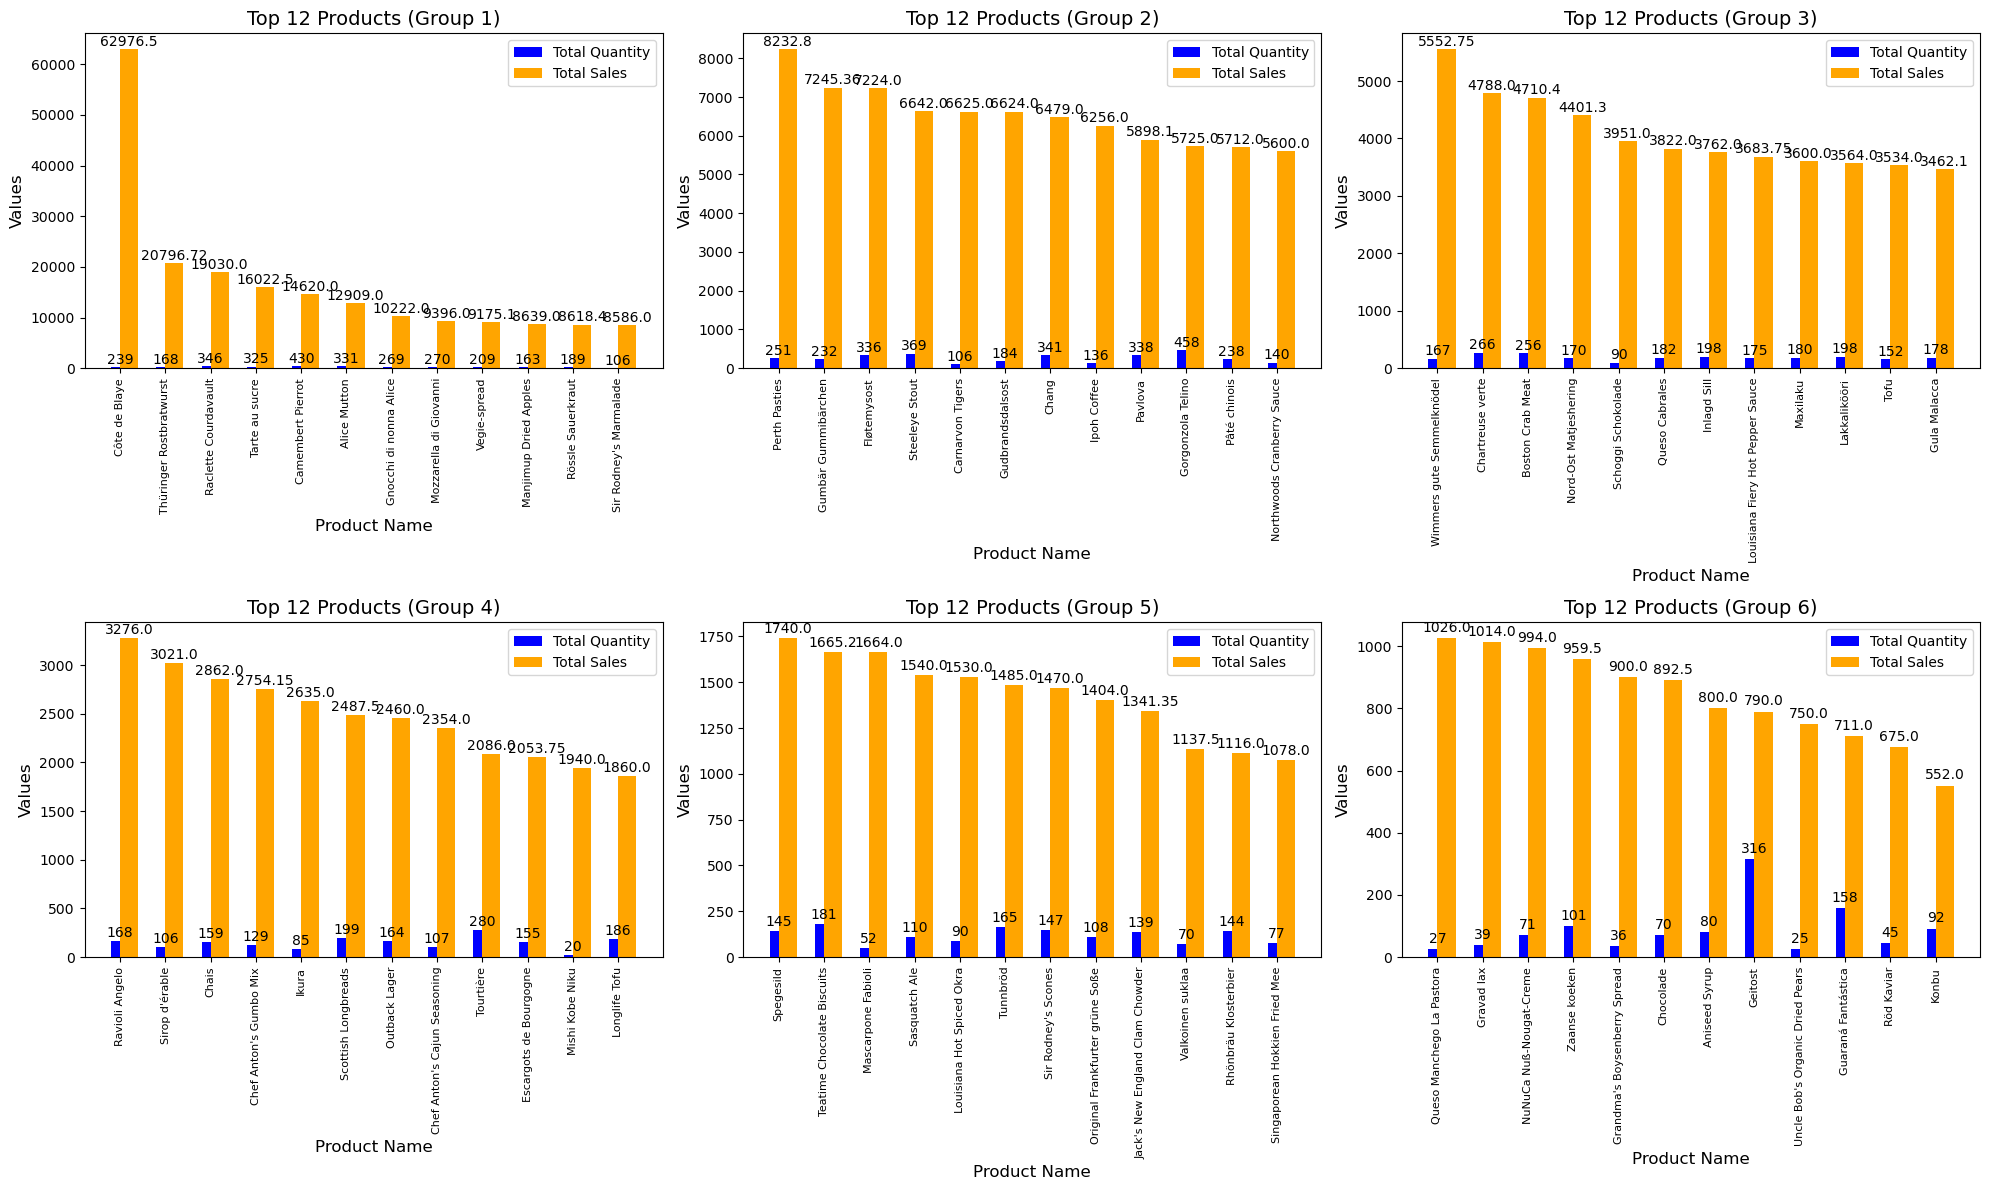

In [1199]:
# افترض أن البيانات تم دمجها وأن لديك DataFrame باسم 'product_summary'
# الذي يحتوي على الأعمدة ['ProductName', 'Total_Quantity', 'Total_Sales']

# إعداد الحجم للمخطط ليكون مناسباً لكل المنتجات
fig, axes = plt.subplots(2, 3, figsize=(20, 12))  # 2 صفوف و 3 أعمدة للحصول على 6 مخططات

# تسطيح المحاور لتسهيل الوصول إليها
axes = axes.flatten()

# تحديد عدد المنتجات في كل مخطط (لتقسيمها إلى 6 مجموعات)
products_per_plot = len(product_summary) // 6  # تقسيم المنتجات على 6 مخططات تقريباً

# تقسيم البيانات إلى 6 مجموعات
product_groups = [product_summary[i:i + products_per_plot] for i in range(0, len(product_summary), products_per_plot)]

# رسم المخططات في الشبكة (2 صفوف × 3 أعمدة)
for i, ax in enumerate(axes):
    if i < len(product_groups):  # إذا كانت المجموعة موجودة
        group = product_groups[i]
        
        # رسم الأعمدة (Total Quantity)
        bars1 = ax.bar(group['ProductName'], group['Total_Quantity'], label='Total Quantity', color='blue', width=0.4, align='center')

        # رسم الأعمدة (Total Sales)
        bars2 = ax.bar(group['ProductName'], group['Total_Sales'], label='Total Sales', color='orange', width=0.4, align='edge')

        # إضافة الأرقام على الأعمدة
        for bar in bars1:
            yval = bar.get_height()  # الحصول على ارتفاع الشريط (القيمة)
            ax.text(bar.get_x() + bar.get_width() / 2, yval + 10, round(yval, 2), ha='center', va='bottom', color='black')

        for bar in bars2:
            yval = bar.get_height()  # الحصول على ارتفاع الشريط (القيمة)
            ax.text(bar.get_x() + bar.get_width() / 2, yval + 10, round(yval, 2), ha='center', va='bottom', color='black')

        # تخصيص العنوان للمخطط
        ax.set_title(f"Top {len(group)} Products (Group {i + 1})", fontsize=14)
        ax.set_ylabel('Values', fontsize=12)

        # إضافة وسيلة الإيضاح (legend)
        ax.legend()

        # إضافة تسميات المحور X (اسم المنتج)
        ax.set_xlabel('Product Name', fontsize=12)
        ax.set_xticklabels(group['ProductName'], rotation=90, fontsize=8)  # تدوير التسميات 90 درجة

# تخصيص المساحة بين المخططات
plt.tight_layout()

# عرض الرسم البياني
plt.show()


Some products generate higher sales despite lower quantities sold, likely due to higher prices. 
In contrast, products with larger quantities sold may generate less revenue due to their lower prices. 
This shows that price plays a crucial role in total sales, 
and profitability is more important than just sales volume.

#### Comparison of Total Sales and Total Quantity by Supplier

In [1191]:
# دمج بيانات OrderDetails مع بيانات المنتجات للحصول على معلومات المورد
order_details_with_supplier = pd.merge(df_OrderDetails, df_Products[['ProductID', 'SupplierID']], on='ProductID', how='left')

# دمج بيانات الموردين للحصول على SupplierName
order_details_with_supplier = pd.merge(order_details_with_supplier, df_Suppliers[['SupplierID', 'SupplierName']], on='SupplierID', how='left')

# دمج مع جدول المنتجات للحصول على السعر وحساب إجمالي المبيعات لكل طلب (Quantity * Price)
order_details_with_supplier = pd.merge(order_details_with_supplier, df_Products[['ProductID', 'Price']], on='ProductID', how='left')
order_details_with_supplier['Total Sales'] = order_details_with_supplier['Quantity'] * order_details_with_supplier['Price']

# تجميع البيانات حسب SupplierName لحساب عدد المنتجات المميزة، إجمالي الكميات وإجمالي المبيعات
supplier_summary = order_details_with_supplier.groupby('SupplierName').agg(
    Product_Count=('ProductID', 'nunique'),  # عدد المنتجات المميزة
    Total_Quantity=('Quantity', 'sum'),  # إجمالي الكميات
    Total_Sales=('Total Sales', 'sum')  # إجمالي المبيعات
).reset_index()

# ترتيب البيانات حسب إجمالي المبيعات من الأعلى إلى الأقل
supplier_summary_sorted = supplier_summary.sort_values(by='Total_Sales', ascending=False)

# عرض النتيجة
supplier_summary_sorted


,SupplierName,Product_Count,Total_Quantity,Total_Sales
0,Aux joyeux ecclésiastiques,2,505,67764.50
23,Plutzer Lebensmittelgroßmärkte AG,5,776,37487.87
22,"Pavlova, Ltd.",5,1148,37067.20
8,Gai pâturage,2,776,33650.00
6,Forêts d'érables,2,431,19043.50
7,"G'day, Mate",3,462,17207.80
5,Formaggi Fortini s.r.l.,3,780,16785.00
19,Norske Meierier,3,836,14638.00
25,"Specialty Biscuits, Ltd.",4,633,14208.70
21,Pasta Buttini s.r.l.,2,437,13498.00


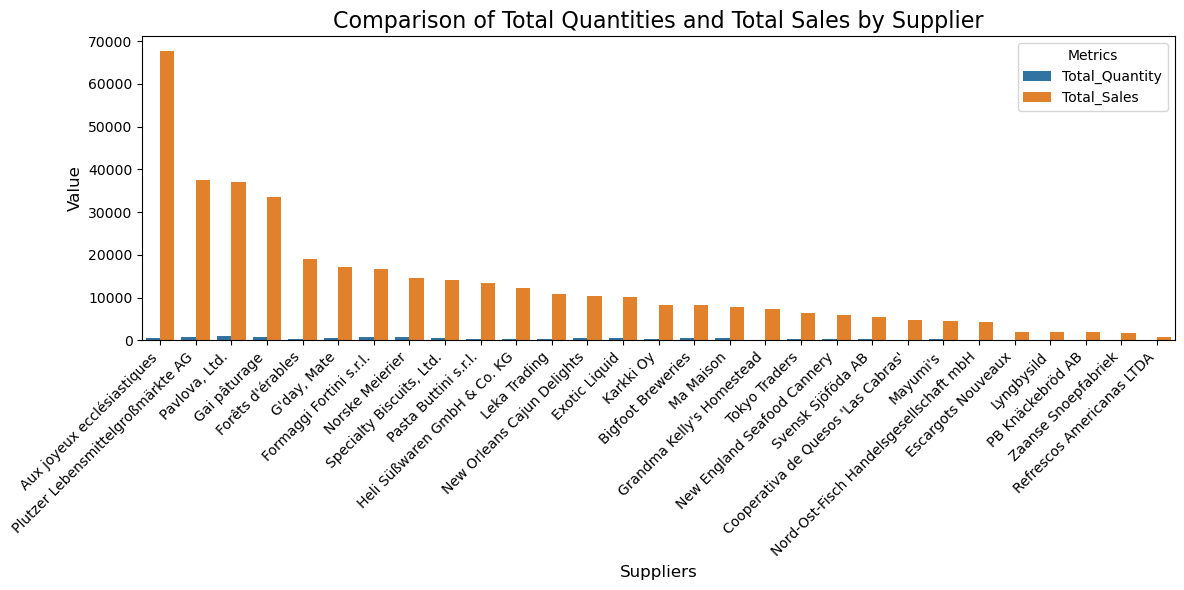

In [1192]:
# ترتيب البيانات حسب إجمالي المبيعات (من الأعلى إلى الأقل)
supplier_summary_sorted = supplier_summary.sort_values(by='Total_Sales', ascending=False)

# إعادة تشكيل البيانات لتسهيل رسم المخطط
supplier_summary_melted = supplier_summary_sorted.melt(id_vars='SupplierName', 
                                                      value_vars=['Total_Quantity', 'Total_Sales'], 
                                                      var_name='Metric', 
                                                      value_name='Value')

# إعداد المخطط
plt.figure(figsize=(12, 6))

# رسم المخطط الشريطي باستخدام seaborn مع تخصيص الألوان لكل مقياس (يدويًا)
sns.barplot(x='SupplierName', y='Value', hue='Metric', data=supplier_summary_melted, dodge=True, 
            palette={'Total_Quantity': '#1f77b4', 'Total_Sales': '#ff7f0e'})

# إضافة تسميات للمخطط باللغة الإنجليزية
plt.title('Comparison of Total Quantities and Total Sales by Supplier', fontsize=16)
plt.xlabel('Suppliers', fontsize=12)
plt.ylabel('Value', fontsize=12)
plt.xticks(rotation=45, ha='right')  # تدوير تسميات المحور X

# تعديل التسمية التوضيحية (legend) بحيث يظهر اللون المتوافق مع كل مقياس
plt.legend(title='Metrics')

# عرض المخطط
plt.tight_layout()
plt.show()


The data shows that some suppliers, like "Pavlova, Ltd." and "Gai pâturage,"
outperform others in terms of total quantities and sales, 
suggesting they may provide more popular or valuable products.
On the other hand, some suppliers, such as "Refrescos Americanas LTDA" 
and "Escargots Nouveaux," offer fewer quantities, which could reflect different market preferences,
strategies, or even distribution challenges.

<a href="#toc" role="button" aria-pressed="true">🔝 Back to Table of Contents 🔝</a>

# <a id="3.10"></a>
## <b>3.10 <span style='color:#F1A424'>Total Sales by price segment </span></b>

In [1193]:
# دمج بيانات الأوامر مع تفاصيل المنتجات للحصول على الفئة السعرية والسعر
orders_with_products = pd.merge(df_OrderDetails, df_Products[['ProductID', 'Price', 'PriceSegment']], on='ProductID', how='left')

# حساب إجمالي المبيعات لكل منتج (Quantity * Price)
orders_with_products['Total Sales'] = orders_with_products['Quantity'] * orders_with_products['Price']

# حساب إجمالي المبيعات لكل طلب داخل كل فئة سعرية
total_sales_by_order_segment = orders_with_products.groupby(['OrderID', 'PriceSegment'])['Total Sales'].sum().reset_index()

# عرض النتائج
total_sales_by_order_segment


,OrderID,PriceSegment,Total Sales
0,10248,Low,140.00
1,10248,Mid,426.00
2,10249,High,2120.00
3,10249,Mid,209.25
4,10250,High,1855.00
...,...,...,...
349,10441,High,2195.00
350,10442,Low,1616.00
351,10442,Mid,630.00
352,10443,High,547.20


In [1194]:
# تحديد الفئة السعرية لكل منتج
df_Products['PriceSegment'] = pd.qcut(df_Products['Price'], q=3, labels=['Low', 'Mid', 'High'])

# دمج بيانات الأوامر مع المنتجات للحصول على الأسعار والفئات
orders_with_products = pd.merge(df_OrderDetails, df_Products[['ProductID', 'Price', 'PriceSegment']], on='ProductID', how='left')

# حساب إجمالي المبيعات لكل منتج (Quantity * Price)
orders_with_products['Total Sales'] = orders_with_products['Quantity'] * orders_with_products['Price']

# تجميع المبيعات حسب الفئة السعرية
sales_by_segment = orders_with_products.groupby('PriceSegment')['Total Sales'].sum().reset_index()

# عرض النتائج
sales_by_segment


C:\Users\LEGION\AppData\Local\Temp\ipykernel_17960\2848486522.py:13: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



,PriceSegment,Total Sales
0,Low,36434.30
1,Mid,87875.80
2,High,262114.13


In [1195]:
import plotly.express as px

# دمج البيانات للحصول على إجمالي المبيعات لكل فئة سعرية
total_sales_by_segment = orders_with_products.groupby('PriceSegment')['Total Sales'].sum().reset_index()

# إنشاء المخطط الشريطي
fig = px.bar(total_sales_by_segment, 
             x='PriceSegment', 
             y='Total Sales', 
             title='Total Sales by Price Segment',  # العنوان بالإنجليزية
             labels={'PriceSegment': 'Price Segment', 'Total Sales': 'Total Sales'},  # تسميات المحاور بالإنجليزية
             color='PriceSegment')

# عرض المخطط
fig.show()


C:\Users\LEGION\AppData\Local\Temp\ipykernel_17960\2741829634.py:4: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

C:\Users\LEGION\anaconda3\Lib\site-packages\plotly\express\_core.py:1958: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



The High segment dominates sales with the highest total, followed by Mid and then Low. 
This indicates that higher-priced products attract the most demand,
while lower-priced products still see sales, but at a lower level.

<a href="#toc" role="button" aria-pressed="true">🔝 Back to Table of Contents 🔝</a>

# <a id="3.11"></a>
## <b>3.13 <span style='color:#F1A424'>Number of Orders and Total Sales Per Employee</span></b>

C:\Users\LEGION\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning:

use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.

C:\Users\LEGION\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning:

use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.



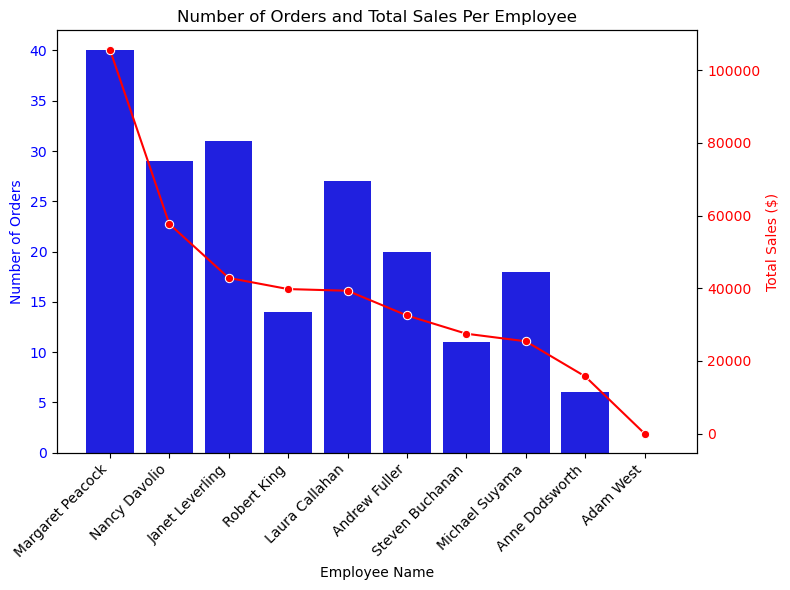

In [1196]:
# 1. أخذ أول 10 موظفين بناءً على إجمالي المبيعات وترتيبهم من الأكبر إلى الأصغر حسب total_sales
employees = df_Employees[['EmployeeID', 'EmployeeName', 'total_orders', 'total_sales']].sort_values(by='total_sales', ascending=False).head(10)

# 2. رسم بياني يعرض عدد الطلبات وإجمالي المبيعات لكل من أول 10 موظفين
fig, ax1 = plt.subplots(figsize=(8, 6))

# رسم عدد الطلبات
sns.barplot(x='EmployeeName', y='total_orders', data=employees, color='b', ax=ax1)
ax1.set_xlabel('Employee Name')
ax1.set_ylabel('Number of Orders', color='b')
ax1.tick_params(axis='y', labelcolor='b')
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')

# إضافة المحور الثاني لإجمالي المبيعات
ax2 = ax1.twinx()
sns.lineplot(x='EmployeeName', y='total_sales', data=employees, color='r', marker='o', ax=ax2)
ax2.set_ylabel('Total Sales ($)', color='r')
ax2.tick_params(axis='y', labelcolor='r')

# عرض الرسم البياني
plt.title('Number of Orders and Total Sales Per Employee')
plt.tight_layout()
plt.show()


The data shows a positive correlation between number of orders and total sales, with employees having more orders generally achieving higher sales, but there are exceptions like Steven Buchanan. To improve performance, focus should be on employees with few orders or low sales.

<a href="#toc" role="button" aria-pressed="true">🔝 Back to Table of Contents 🔝</a>

# <a id="3.12"></a>
## <b>3.12 <span style='color:#F1A424'>Total Sales and Total Orders in Each Shipper Company</span></b>

In [1197]:
# 1. حساب إجمالي المبيعات وعدد الطلبات لكل شركة شحن في df_Orders
df_shipper_summary = df_Orders.groupby('ShipperID').agg(
    TotalSales=('Total Sales', 'sum'),   # إجمالي المبيعات
    TotalOrders=('OrderID', 'nunique')   # عدد الطلبات الفريدة
).reset_index()

# 2. دمج البيانات الجديدة مع جدول شركات الشحن (df_Shippers)
df_shipper_summary = pd.merge(df_Shippers, df_shipper_summary, on='ShipperID', how='left')

# 3. حذف العمود الزائد "TotalOrders_x" أو أي عمود مكرر
# تحقق من وجود الأعمدة المكررة (TotalOrders_x أو TotalOrders_y)
df_shipper_summary = df_shipper_summary.drop(columns=['TotalOrders_x'], errors='ignore')

# 4. إعادة تسمية الأعمدة إذا كان هناك أي لبس
df_shipper_summary.rename(columns={'TotalOrders_y': 'TotalOrders'}, inplace=True)

# 5. عرض النتيجة: جدول يحتوي على اسم شركة الشحن، إجمالي المبيعات، وإجمالي الطلبات
df_shipper_summary[['ShipperName', 'TotalSales', 'TotalOrders']]


,ShipperName,TotalSales,TotalOrders
0,Speedy Express,95684.68,54
1,United Package,155152.03,74
2,Federal Shipping,135587.52,68


C:\Users\LEGION\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning:

use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.

C:\Users\LEGION\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning:

use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.



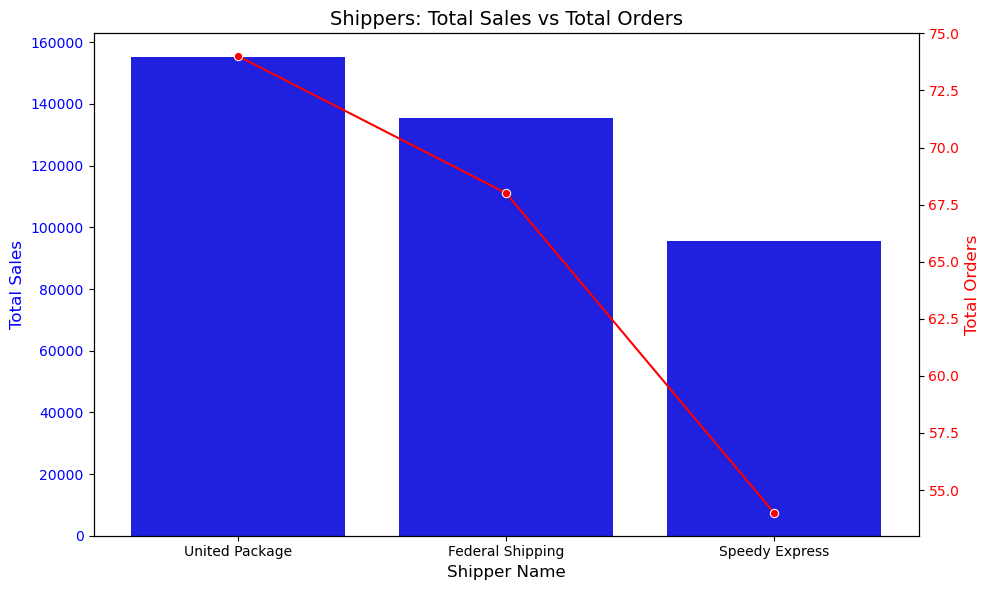

In [1198]:
# 1. ترتيب البيانات حسب إجمالي المبيعات من الأكبر إلى الأصغر
df_shipper_summary_sorted = df_shipper_summary.sort_values(by='TotalSales', ascending=False)

# 2. إعداد المخطط
fig, ax1 = plt.subplots(figsize=(10, 6))

# 3. رسم إجمالي المبيعات باستخدام barplot
sns.barplot(x='ShipperName', y='TotalSales', data=df_shipper_summary_sorted, color='b', ax=ax1)
ax1.set_xlabel('Shipper Name', fontsize=12)
ax1.set_ylabel('Total Sales', color='b', fontsize=12)
ax1.tick_params(axis='y', labelcolor='b')

# 4. إضافة المحور الثاني لإجمالي عدد الطلبات
ax2 = ax1.twinx()  # لإنشاء المحور الثاني
sns.lineplot(x='ShipperName', y='TotalOrders', data=df_shipper_summary_sorted, color='r', marker='o', ax=ax2)
ax2.set_ylabel('Total Orders', color='r', fontsize=12)
ax2.tick_params(axis='y', labelcolor='r')

# 5. تنسيق المخطط
plt.title('Shippers: Total Sales vs Total Orders', fontsize=14)
plt.xticks(rotation=45, ha='right')  # تدوير أسماء الشركات لتناسب المحور x
plt.tight_layout()

# 6. عرض المخطط
plt.show()


The company United Package leads in sales among the three shippers, followed by Federal Shipping and Speedy Express. There is a general balance between sales and the number of orders for each company, with United Package outperforming in both areas.

<a href="#toc" role="button" aria-pressed="true">🔝 Back to Table of Contents 🔝</a>

<a id="4"></a>
# <b>4 <span style='color:#F1A424'>|</span>Insights</b>

High-priced products represent 24% of total sales:
A significant portion of these sales comes from high prices for certain products that are sold in larger units.
These products generate higher sales despite fewer units sold,
indicating that higher prices play a key role in boosting total revenue.

Seasonal demand:
High-priced products perform better in winter, with sales reaching 51,585.91, followed by fall at 34,272.56,
while summer shows the lowest sales at 8,440.75. 
This suggests that certain high-priced products experience higher demand in specific seasons, 
reflecting the impact of seasonality on consumer behavior.

Variation in demand across products:
Products like Côte de Blaye generated significantly higher sales, while Mishi Kobe Niku had much lower sales, 
indicating large disparities in demand between products. 
These differences could be due to seasonal factors, promotional campaigns, or changes in market preferences.

Pricing and its impact on revenue:
Products that are sold in larger units or have higher prices contribute significantly to higher revenue, 
even if fewer units are sold. 
It's important to note that higher prices play a central role in achieving higher sales, making profitability more important than just sales volume.

Stock shortages and their impact on demand:
Data shows a large stock shortage (93.5% of products are out of stock),which means there is unmet demand for certain products.
This shortage could affect the company's ability to fulfill orders during peak seasons, such as winter and fall.

Performance variations across regions:
The United States leads in total sales, followed by Germany and Austria, 
while some countries like Argentina and Poland show weak sales. 
This suggests there are opportunities to expand marketing efforts in these countries or improve strategies in markets with weak performance.

Category performance:
Dairy products lead in total sales, surpassing beverages, despite beverages having some of the top-selling items.
This indicates that higher prices in categories like dairy significantly boost revenue compared to lower-priced categories like grains/cereals and produce.

Supplier performance:
Suppliers like Pavlova, Ltd. and Gai pâturage are performing well in terms of sales and quantity,
indicating they offer higher-value or more popular products. 
Conversely, suppliers like Refrescos Americanas LTDA are lagging in sales,
possibly due to distribution challenges or different market strategies.

Shipping performance:
United Package outperforms in both sales and order volume, suggesting that its shipping strategy is the most efficient.
Federal Shipping and Speedy Express show a more balanced performance, but still have some differences in results.

<a href="#toc" role="button" aria-pressed="true">🔝 Back to Table of Contents 🔝</a>

<a id="5"></a>
# <b>5 <span style='color:#F1A424'>|</span>Recommendation</b>

Review pricing strategy:
Since high-priced products contribute significantly to revenue, it's essential to review the pricing strategy for these products regularly to maximize sales and profitability.

Improve inventory management:
Increase stock of high-priced products to meet demand during peak seasons (like winter and fall) and avoid stockouts that could hinder order fulfillment.

Targeted seasonal strategies:
Design marketing campaigns that target high-priced products during the peak seasons (winter and fall) to boost sales during these periods.

Focus on underperforming markets:
Focus on weak markets such as Argentina and Poland, and improve marketing and distribution strategies to increase market share.

Optimize supplier distribution:
Work on improving distribution with suppliers like Refrescos Americanas LTDA to offer more in-demand products or adjust distribution strategies to ensure better performance in weak categories.

Employee performance review:
Analyze employees with few orders but high expenditure as they may represent high-value customers. Also, focus on employees with low sales to help improve their performance through training or support.

Improve shipping strategies:
Since United Package leads in sales and orders, study how to replicate or expand their logistical model. Additionally, work on improving Federal Shipping and Speedy Express to boost overall performance.

<a href="#toc" role="button" aria-pressed="true">🔝 Back to Table of Contents 🔝</a>